In [7]:
#All necessary imports and their dependencies
import numpy as np
import os
import pytraj as pt
import mdtraj as mdt
from pathlib import Path
import pandas as pd
import json
from pytraj import matrix
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import curve_fit
import csv 

#Plot parameters set at the top for all figures
#plt.rc('legend',fontsize=12)
plt.rcParams['font.size']=12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
#plt.gcf().savefig("test.png",dpi=300)
plt.rc('legend',fontsize=12)

#change path as needed
path='/Users/alecloftus/Desktop/ABLIM_CG_Extended_Analyses/tension_pCa'
os.chdir(path)
print(path)
#EXPLANATION OF GOOGLE DRIVE FILES

#kforce_5 is WT
#kforce_174 is GSK knockout (k-force 1.74)
#kforce_174_k1_2_slack1000_lin7 is the RESTORED GSK knockout where k1,slack and lin were modified settings to restore stress to WT levels


/Users/alecloftus/Desktop/ABLIM_CG_Extended_Analyses/tension_pCa


[-344.271151198233, 3306.76083581735, 8836.39138936911, 16844.3652521565, 33390.4810264617, 55405.0286019026, 66227.792891446, 76117.6017155869, 84913.2579214119, 92698.055658064, 105494.338718974, 122630.736403979, 144976.215546082]
[-906.703562725428, 1327.45817330131, 19604.2030386597, 47077.4820014136, 73618.0311376333, 96254.2157012387, 105972.602139986, 114658.852192698, 122377.433095295, 129205.155252081, 140517.947721, 155957.535043383, 176726.348328188]
[1408.08879001084, 7293.29590076726, 17101.1106754034, 30402.6482695445, 51722.1860456263, 75063.8683129076, 85851.034406521, 95662.980795963, 104446.209485455, 112239.407971293, 125134.819070534, 142579.087279426, 165544.592691047]


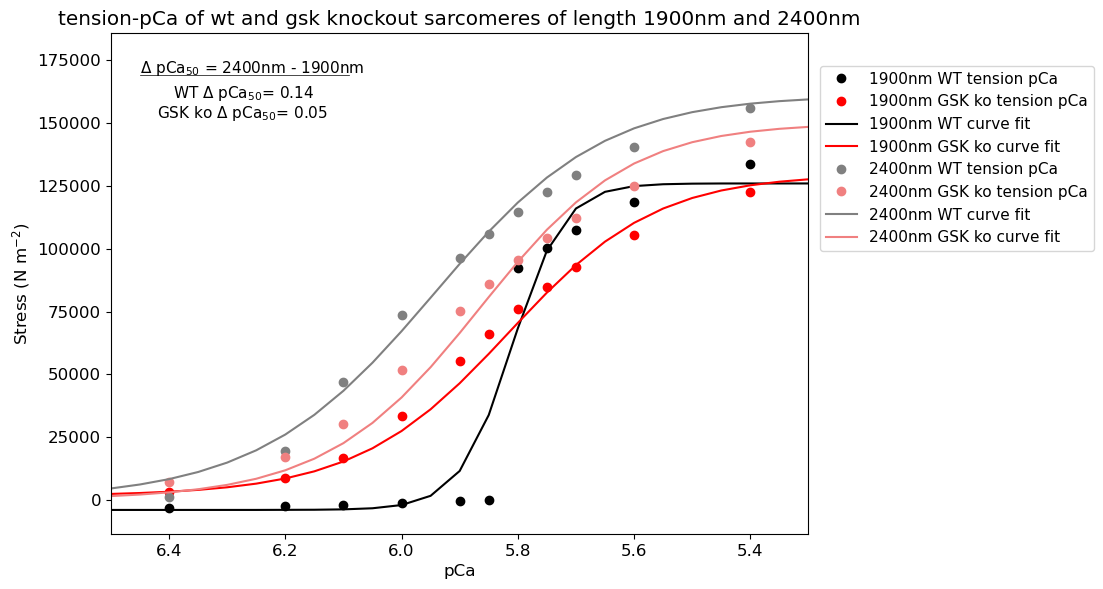

In [38]:
#MATLAB LDA tension-pCa of WT and restored gsk-knockout hsl 950 and 1200 


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit

#x-tick values copied over from the defaults & added x-axis values in MATLAB
x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl950'
wt=csv_file + '_kforce5.csv'
#print(wt)
#gsk=csv_file + '_kforce174_restored.csv' 
gsk=csv_file + '_kforce174_k1_2_slack1000_lin7.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))


gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
print(list_of_gsk)


fig,ax = plt.subplots()



plt.xlim(5.3,6.5)
plt.gca().invert_xaxis()

wt50=5.81
gsk50=5.82 #5.73
#gsk50=5.51

F=130000
#G=100000
G=127000



def hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-4000



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-130))

#print(line_items)
#for i in range(
    
#hill_co=2

def hill_GSK_function(G,Ca50,Ca,n):
    return (G+1000)/(1+(Ca50/Ca)**n)+1500 #-4000



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-45))




#plot 1900nm stuff
plt.plot(x_values,list_of_wt,'ko',label='1900nm WT tension pCa')
plt.plot(x_values,list_of_gsk,'ro',label='1900nm GSK ko tension pCa')
plt.plot(pCa_sequence,line_items,'k-',label='1900nm WT curve fit')
plt.plot(GSK_sequence,gsk_line_items,'r-',label='1900nm GSK ko curve fit')


long_csv='hsl1200'
#LONG STUFF
long_wt=long_csv + '_kforce5.csv'
#print(wt)
long_gsk=long_csv + '_kforce174_k1_2_slack1000_lin7.csv'
#wt_obj = open(wt, 'r')



long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
#print(type(list_of_wt[0]))


print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])


print(list_of_long_gsk)


long_wt50=5.95
long_gsk50=5.87

long_F=161000
long_G=150000


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-40))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-45))


#plot 2600nm stuff
plt.plot(x_values,list_of_long_wt,'o',label='2400nm WT tension pCa',color='gray')
plt.plot(x_values,list_of_long_gsk,'o',label='2400nm GSK ko tension pCa',color='lightcoral')
plt.plot(long_pCa_sequence,long_line_items,'-',label='2400nm WT curve fit',color='gray')
plt.plot(long_GSK_sequence,long_gsk_line_items,'-',label='2400nm GSK ko curve fit',color='lightcoral')


plt.plot([6.45,6.090],[169000,169000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,170000,"\u0394 pCa$_{50}$ = 2400nm - 1900nm", fontsize=11)
plt.text(6.394,160000,text,fontsize=11)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.421,152000,gsk_text,fontsize=11)
plt.legend()
plt.legend(bbox_to_anchor=(1.42,0.75),loc='center right',fontsize=11)

ax.figure.set_size_inches(9.0,6.5)
title="tension-pCa of wt and gsk knockout sarcomeres of length 1900nm and 2400nm"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='pCa_hsl950_vs_hsl1200_restored.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300)
plt.show()


[-3147.10720472144, -1959.52803060485, -1237.03303817737, -725.515563940749, -83.5857810806037, 75246.8173596963, 85657.4592715174, 94556.6810246064, 102340.342436385, 109167.562628868, 120371.062502117, 135486.307309632, 155642.082789067]
[2.89694385034735, 2823.42888335648, 13685.0800559512, 34616.1311992923, 59646.7018108344, 81750.1438012293, 91260.8446467179, 99737.9030952121, 107246.172115362, 113866.725458332, 124791.056787197, 139621.247734719, 159517.581359306]
[-2202.10720472144, -1014.52803060485, -292.033038177369, 24312.7353209841, 54083.0218955402, 77467.7365022482, 87391.1541248875, 96133.4975882871, 103829.19866613, 110590.587348829, 121706.197715937, 136732.5855136, 156808.175918569]
[-942.10720472144, 593.010802514122, 8687.2132339598, 31049.8130153943, 57340.2890972697, 79957.2565617943, 89621.7984645932, 98205.3430386795, 105791.007399032, 112469.954201965, 123474.034757764, 138386.481005904, 158358.338128675]


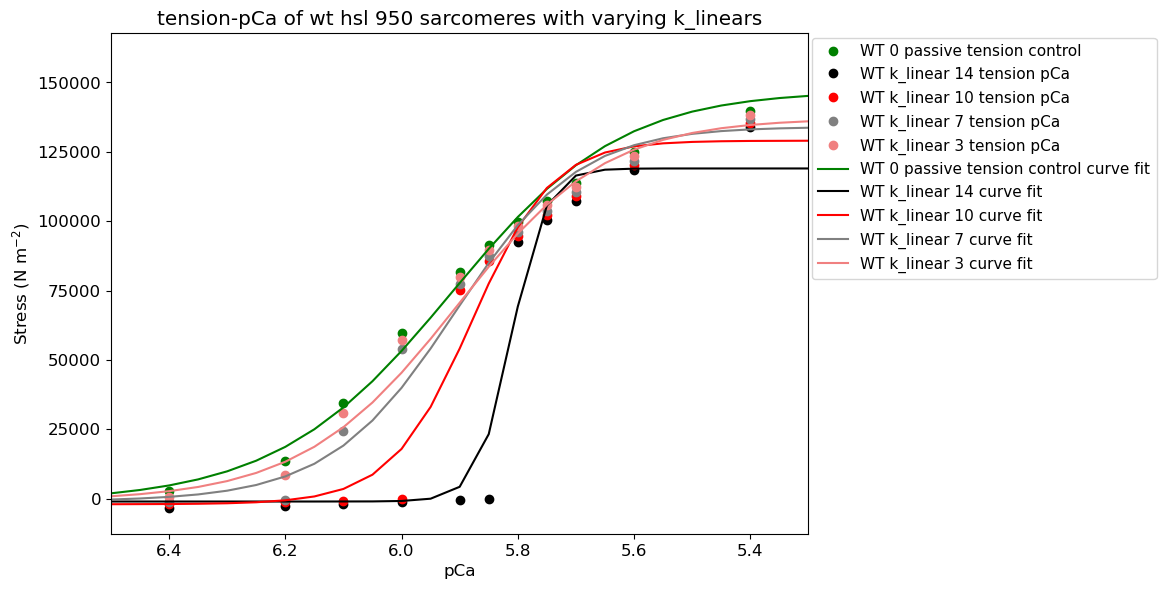

In [170]:
#MATLAB LDA tension-pCa of WT and restored gsk-knockout hsl 950 and 1200 


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit

#x-tick values copied over from the defaults & added x-axis values in MATLAB
x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl950'
wt=csv_file + '_kforce5_klin14_slack1265.csv'
#print(wt)
#gsk=csv_file + '_kforce174_restored.csv' 
gsk=csv_file + '_kforce5_klin10_slack1265.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))


gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
print(list_of_gsk)


fig,ax = plt.subplots()



plt.xlim(5.3,6.5)
plt.gca().invert_xaxis()

wt50=5.81
gsk50=5.88 #5.73
#gsk50=5.51

F=120000
#G=100000
G=130000



def hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-1000



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-200))

#print(line_items)
#for i in range(
    
#hill_co=2

def hill_GSK_function(G,Ca50,Ca,n):
    return (G+1000)/(1+(Ca50/Ca)**n)-2000 #-4000



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-85))

#PASSIVE 0 HILL FUNCTION#
passive=csv_file + '_kforce5_klin14_slack950.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)

for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

#PASSIVE 0 HILL FUNCTION
P=148400
p50=5.92
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)-1500

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-40))


plt.plot(x_values,list_of_passive,'go',label='WT 0 passive tension control')



#plot 1900nm stuff
plt.plot(x_values,list_of_wt,'ko',label='WT k_linear 14 tension pCa')
plt.plot(x_values,list_of_gsk,'ro',label='WT k_linear 10 tension pCa')



long_csv='hsl950'
#LONG STUFF
long_wt=long_csv + '_kforce5_klin7_slack1265.csv'
#print(wt)
long_gsk=long_csv + '_kforce5_klin3_slack1265.csv'
#wt_obj = open(wt, 'r')



long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
#print(type(list_of_wt[0]))


print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])


print(list_of_long_gsk)


long_wt50=5.91
long_gsk50=5.91

long_F=135000
long_G=138000


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-1000

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)-1000

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-55))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-45))


#plot 2600nm stuff
plt.plot(x_values,list_of_long_wt,'o',label='WT k_linear 7 tension pCa',color='gray')
plt.plot(x_values,list_of_long_gsk,'o',label='WT k_linear 3 tension pCa',color='lightcoral')

plt.plot(passive_sequence,passive_line_items,'g-',label='WT 0 passive tension control curve fit')
plt.plot(pCa_sequence,line_items,'k-',label='WT k_linear 14 curve fit')
plt.plot(GSK_sequence,gsk_line_items,'r-',label='WT k_linear 10 curve fit')
plt.plot(long_pCa_sequence,long_line_items,'-',label='WT k_linear 7 curve fit',color='gray')
plt.plot(long_GSK_sequence,long_gsk_line_items,'-',label='WT k_linear 3 curve fit',color='lightcoral')

'''
plt.plot([6.45,6.090],[169000,169000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,170000,"\u0394 pCa$_{50}$ = 2400nm - 1900nm", fontsize=11)
plt.text(6.394,160000,text,fontsize=11)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.421,152000,gsk_text,fontsize=11)
'''
plt.legend()
plt.legend(bbox_to_anchor=(1.51,0.75),loc='center right',fontsize=11)

ax.figure.set_size_inches(9.0,6.5)
title="tension-pCa of wt hsl 950 sarcomeres with varying k_linears"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='pCa_hsl950_WT_klins.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300)
plt.show()


[-3147.10720472144, -1959.52803060485, -1237.03303817737, -725.515563940749, -83.5857810806037, 2007.07623286115, 4021.25021859501, 7705.37377942344, 12066.0279769315, 18976.0507768322, 40187.8905183422, 66481.5278095624, 97844.2012038469]
[2.89423764639342, 1495.6362346248, 2838.42260304338, 4114.96660357619, 6308.2591247069, 10434.2587569567, 13842.3917782032, 18966.1048401717, 24830.8536127552, 32359.2954372681, 49521.5922038007, 73409.6597600314, 103279.35419941]
[-2202.10720472144, -1014.52803060485, -292.033038177369, 375.158009115522, 1798.89494950593, 4624.24910502476, 7132.09959540315, 11415.7633293672, 16371.0208215522, 23632.6674100902, 43195.0512765788, 68625.9436511592, 99496.8028011709]
[-942.10720472144, 308.59115969253, 1438.58972222011, 2518.58801278113, 4391.83633198536, 7992.31670516904, 11052.3429433546, 15882.1219347099, 21427.1693666254, 28900.1171995657, 46908.6121298412, 71393.8979321791, 101670.282944995]


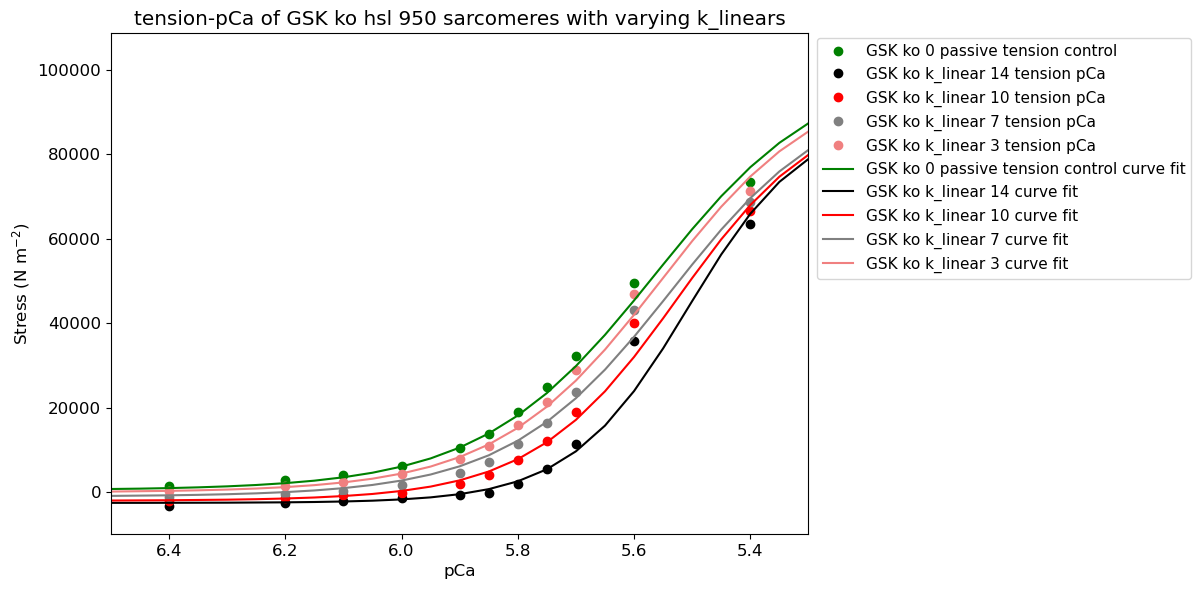

In [171]:
#MATLAB LDA tension-pCa of WT and restored gsk-knockout hsl 950 and 1200 


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit

#x-tick values copied over from the defaults & added x-axis values in MATLAB
x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl950'
wt=csv_file + '_kforce174_klin14_slack1265.csv'
#print(wt)
#gsk=csv_file + '_kforce174_restored.csv' 
gsk=csv_file + '_kforce174_klin10_slack1265.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))


gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
print(list_of_gsk)


fig,ax = plt.subplots()



plt.xlim(5.3,6.5)
plt.gca().invert_xaxis()

wt50=5.51
gsk50=5.53 #5.73
#gsk50=5.51

F=91000
#G=100000
G=93000



def hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-2500



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-55))

#print(line_items)
#for i in range(
    
#hill_co=2

def hill_GSK_function(G,Ca50,Ca,n):
    return (G+1000)/(1+(Ca50/Ca)**n)-2000 #-4000



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-45))

#PASSIVE 0 HILL FUNCTION#
passive=csv_file + '_kforce174_klin14_slack950.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)

for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

#PASSIVE 0 HILL FUNCTION
P=100000
p50=5.57
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)+500

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-38))


plt.plot(x_values,list_of_passive,'go',label='GSK ko 0 passive tension control')



#plot 1900nm stuff
plt.plot(x_values,list_of_wt,'ko',label='GSK ko k_linear 14 tension pCa')
plt.plot(x_values,list_of_gsk,'ro',label='GSK ko k_linear 10 tension pCa')



long_csv='hsl950'
#LONG STUFF
long_wt=long_csv + '_kforce174_klin7_slack1265.csv'
#print(wt)
long_gsk=long_csv + '_kforce174_klin3_slack1265.csv'
#wt_obj = open(wt, 'r')



long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
#print(type(list_of_wt[0]))


print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])


print(list_of_long_gsk)


long_wt50=5.54
long_gsk50=5.56

long_F=96000
long_G=98000


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-1000

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-40))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-40))


#plot 2600nm stuff
plt.plot(x_values,list_of_long_wt,'o',label='GSK ko k_linear 7 tension pCa',color='gray')
plt.plot(x_values,list_of_long_gsk,'o',label='GSK ko k_linear 3 tension pCa',color='lightcoral')

plt.plot(passive_sequence,passive_line_items,'g-',label='GSK ko 0 passive tension control curve fit')
plt.plot(pCa_sequence,line_items,'k-',label='GSK ko k_linear 14 curve fit')
plt.plot(GSK_sequence,gsk_line_items,'r-',label='GSK ko k_linear 10 curve fit')
plt.plot(long_pCa_sequence,long_line_items,'-',label='GSK ko k_linear 7 curve fit',color='gray')
plt.plot(long_GSK_sequence,long_gsk_line_items,'-',label='GSK ko k_linear 3 curve fit',color='lightcoral')

'''
plt.plot([6.45,6.090],[169000,169000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,170000,"\u0394 pCa$_{50}$ = 2400nm - 1900nm", fontsize=11)
plt.text(6.394,160000,text,fontsize=11)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.421,152000,gsk_text,fontsize=11)
'''
plt.legend()
plt.legend(bbox_to_anchor=(1.56,0.75),loc='center right',fontsize=11)

ax.figure.set_size_inches(9.0,6.5)
title="tension-pCa of GSK ko hsl 950 sarcomeres with varying k_linears"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='pCa_hsl950_GSKko_klins.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300)
plt.show()


[-3146.70356272543, -1794.06944131459, -971.79546486963, -389.925959667107, 68699.3205335133, 92285.3522193901, 102314.995111767, 111208.310265727, 119078.30854982, 126021.539378551, 137494.176140121, 153101.547632292, 174027.160736792]
[3.30182540839688, 3914.49393371346, 23977.797528995, 49731.2799271996, 75519.5412899629, 97815.24445935, 107430.423942492, 116040.859274818, 123702.271483, 130486.020813196, 141737.397691769, 157111.865166533, 177819.250044037]
[-2201.70356272543, -849.069441314587, -26.7954648696295, 42916.9831220108, 70819.9876259699, 93990.8804905306, 103871.388883071, 112672.784811453, 120476.951451013, 127370.119387428, 138773.752151447, 154308.995026706, 175167.461559683]
[-941.703562725428, 1224.80452167817, 19410.8566905676, 46971.6510311321, 73543.8881210392, 96193.7362706685, 105916.235256537, 114605.478697549, 122326.305891294, 129155.751561361, 140470.94505894, 155913.070884932, 176684.272295923]


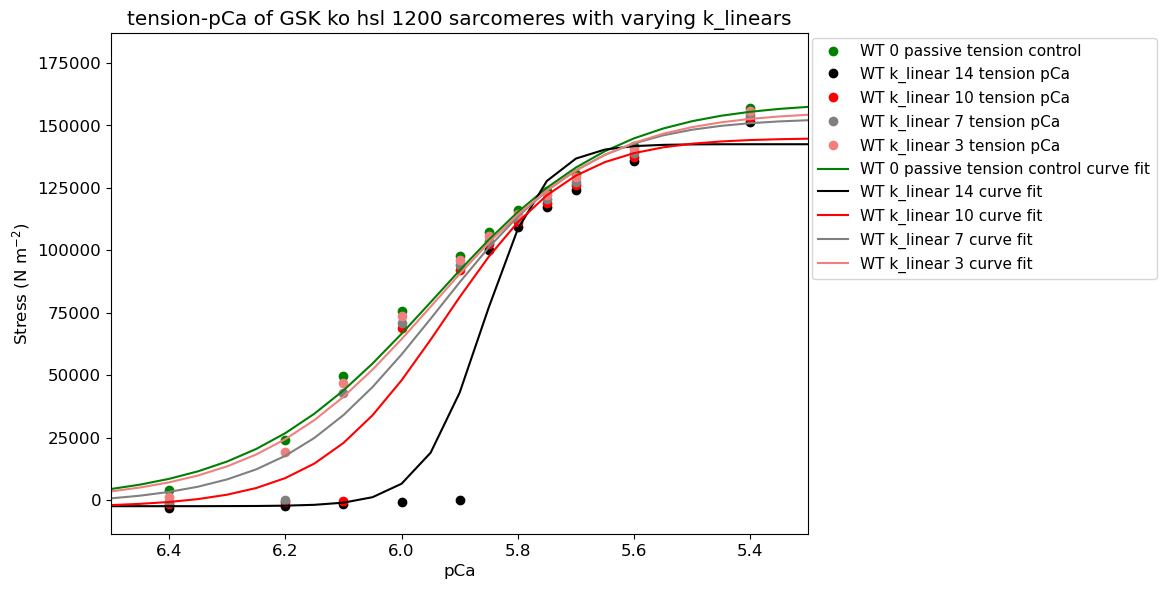

In [172]:
#MATLAB LDA tension-pCa of WT and restored gsk-knockout hsl 950 and 1200 


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit

#x-tick values copied over from the defaults & added x-axis values in MATLAB
x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl1200'
wt=csv_file + '_kforce5_klin14_slack1515.csv'
#print(wt)
#gsk=csv_file + '_kforce174_restored.csv' 
gsk=csv_file + '_kforce5_klin10_slack1515.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))


gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
print(list_of_gsk)


fig,ax = plt.subplots()



plt.xlim(5.3,6.5)
plt.gca().invert_xaxis()

wt50=5.86
gsk50=5.93 #5.73
#gsk50=5.51

F=145000
#G=100000
G=147000



def hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-2500



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-115))

#print(line_items)
#for i in range(
    
#hill_co=2

def hill_GSK_function(G,Ca50,Ca,n):
    return (G+1000)/(1+(Ca50/Ca)**n)-3000 #-4000



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-55))

#PASSIVE 0 HILL FUNCTION#
passive=csv_file + '_kforce5_klin14_slack1200.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)

for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

#PASSIVE 0 HILL FUNCTION
P=160400
p50=5.95
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)-1000

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-38))


plt.plot(x_values,list_of_passive,'go',label='WT 0 passive tension control')



#plot 1900nm stuff
plt.plot(x_values,list_of_wt,'ko',label='WT k_linear 14 tension pCa')
plt.plot(x_values,list_of_gsk,'ro',label='WT k_linear 10 tension pCa')



long_csv='hsl1200'
#LONG STUFF
long_wt=long_csv + '_kforce5_klin7_slack1515.csv'
#print(wt)
long_gsk=long_csv + '_kforce5_klin3_slack1515.csv'
#wt_obj = open(wt, 'r')



long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
#print(type(list_of_wt[0]))


print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])


print(list_of_long_gsk)


long_wt50=5.94
long_gsk50=5.95

long_F=155000
long_G=156800


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-2000

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)-1000

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-45))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-40))


#plot 2600nm stuff
plt.plot(x_values,list_of_long_wt,'o',label='WT k_linear 7 tension pCa',color='gray')
plt.plot(x_values,list_of_long_gsk,'o',label='WT k_linear 3 tension pCa',color='lightcoral')

plt.plot(passive_sequence,passive_line_items,'g-',label='WT 0 passive tension control curve fit')
plt.plot(pCa_sequence,line_items,'k-',label='WT k_linear 14 curve fit')
plt.plot(GSK_sequence,gsk_line_items,'r-',label='WT k_linear 10 curve fit')
plt.plot(long_pCa_sequence,long_line_items,'-',label='WT k_linear 7 curve fit',color='gray')
plt.plot(long_GSK_sequence,long_gsk_line_items,'-',label='WT k_linear 3 curve fit',color='lightcoral')

'''
plt.plot([6.45,6.090],[169000,169000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,170000,"\u0394 pCa$_{50}$ = 2400nm - 1900nm", fontsize=11)
plt.text(6.394,160000,text,fontsize=11)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.421,152000,gsk_text,fontsize=11)
'''
plt.legend()
plt.legend(bbox_to_anchor=(1.51,0.75),loc='center right',fontsize=11)

ax.figure.set_size_inches(9.0,6.5)
title="tension-pCa of GSK ko hsl 1200 sarcomeres with varying k_linears"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='pCa_hsl1200_WT_klins.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300)
plt.show()


[-3146.70356272543, -1794.06944131459, -971.79546486963, -389.925959667107, 837.436774959575, 4460.21874981399, 8080.58434788682, 15869.8768671551, 22292.5592126892, 32928.8780788087, 57725.0252808754, 84525.8715067034, 116501.621978555]
[3.29831036897353, 1765.80675660842, 3458.81169790046, 5163.92015132254, 8301.09603218573, 14630.5281004341, 20009.7747972315, 28327.6189465948, 36344.6767462036, 46248.6948597126, 65788.4024138607, 90780.4069171115, 121605.940333223]
[-2201.70356272543, -849.069441314587, -26.7954648696295, 1049.27013545129, 3130.62352422589, 7687.48120126559, 11981.9725832434, 20108.817727696, 27220.9630260472, 37673.5642711419, 60256.6683042804, 86442.2345355317, 118048.004837091]
[-941.703562725428, 535.578683965808, 1962.59989699795, 3410.71902300964, 6114.26721522879, 11746.7467676711, 16729.158010217, 25016.2332846247, 32744.2406199466, 42882.2206455635, 63474.5496267914, 88942.5951188172, 120089.420697924]


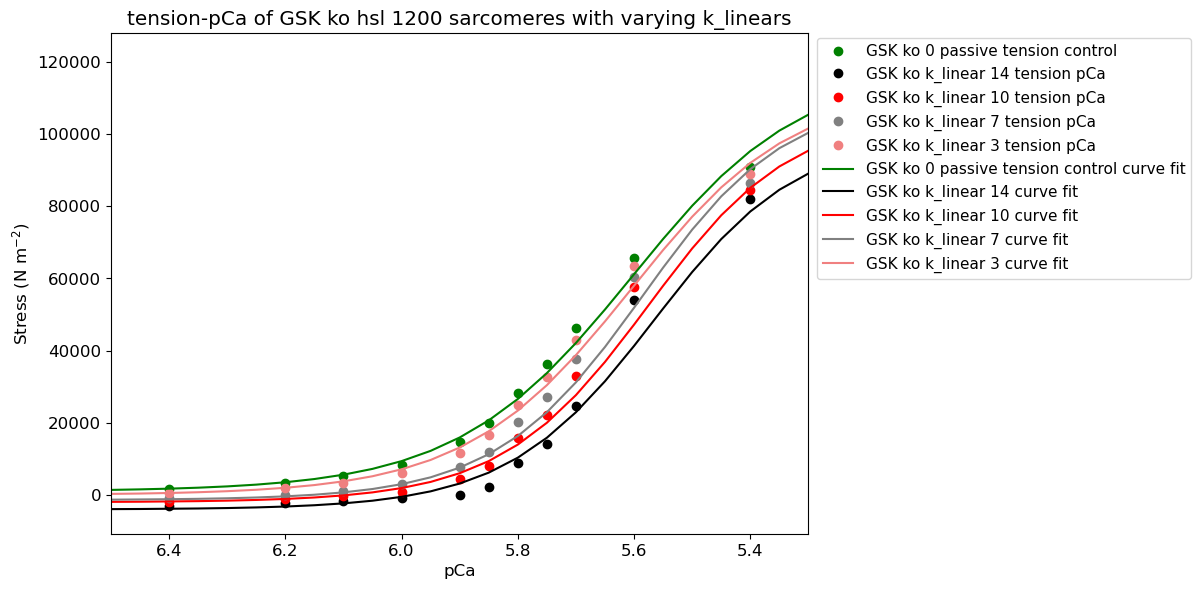

In [177]:
#MATLAB LDA tension-pCa of gsk-knockout hsl 1200


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit

#x-tick values copied over from the defaults & added x-axis values in MATLAB
x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl1200'
wt=csv_file + '_kforce174_klin14_slack1515.csv'
#print(wt)
#gsk=csv_file + '_kforce174_restored.csv' 
gsk=csv_file + '_kforce174_klin10_slack1515.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))


gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
print(list_of_gsk)


fig,ax = plt.subplots()



plt.xlim(5.3,6.5)
plt.gca().invert_xaxis()

wt50=5.57
gsk50=5.58 #5.73
#gsk50=5.51

F=103000
#G=100000
G=106000



def hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-4000



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-45))

#print(line_items)
#for i in range(
    
#hill_co=2

def hill_GSK_function(G,Ca50,Ca,n):
    return (G+1000)/(1+(Ca50/Ca)**n)-2000 #-4000



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-45))

#PASSIVE 0 HILL FUNCTION#
passive=csv_file + '_kforce174_klin14_slack1200.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)

for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

#PASSIVE 0 HILL FUNCTION
P=116400
p50=5.61
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)+1000

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-38))


plt.plot(x_values,list_of_passive,'go',label='GSK ko 0 passive tension control')


plt.plot(x_values,list_of_wt,'ko',label='GSK ko k_linear 14 tension pCa')
plt.plot(x_values,list_of_gsk,'ro',label='GSK ko k_linear 10 tension pCa')



long_csv='hsl1200'
#LONG STUFF
long_wt=long_csv + '_kforce174_klin7_slack1515.csv'
#print(wt)
long_gsk=long_csv + '_kforce174_klin3_slack1515.csv'
#wt_obj = open(wt, 'r')



long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
#print(type(list_of_wt[0]))


print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])


print(list_of_long_gsk)


long_wt50=5.59
long_gsk50=5.61

long_F=111000
long_G=112000


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)-1400

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-45))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-40))


#plot 2600nm stuff
plt.plot(x_values,list_of_long_wt,'o',label='GSK ko k_linear 7 tension pCa',color='gray')
plt.plot(x_values,list_of_long_gsk,'o',label='GSK ko k_linear 3 tension pCa',color='lightcoral')

plt.plot(passive_sequence,passive_line_items,'g-',label='GSK ko 0 passive tension control curve fit')
plt.plot(pCa_sequence,line_items,'k-',label='GSK ko k_linear 14 curve fit')
plt.plot(GSK_sequence,gsk_line_items,'r-',label='GSK ko k_linear 10 curve fit')
plt.plot(long_pCa_sequence,long_line_items,'-',label='GSK ko k_linear 7 curve fit',color='gray')
plt.plot(long_GSK_sequence,long_gsk_line_items,'-',label='GSK ko k_linear 3 curve fit',color='lightcoral')

'''
plt.plot([6.45,6.090],[169000,169000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,170000,"\u0394 pCa$_{50}$ = 2400nm - 1900nm", fontsize=11)
plt.text(6.394,160000,text,fontsize=11)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.421,152000,gsk_text,fontsize=11)
'''
plt.legend()
plt.legend(bbox_to_anchor=(1.56,0.75),loc='center right',fontsize=11)

ax.figure.set_size_inches(9.0,6.5)
title="tension-pCa of GSK ko hsl 1200 sarcomeres with varying k_linears"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='pCa_hsl1200_GSKko_klins.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300)
plt.show()


[3505.27512268891, 6305.30803960039, 8944.48488534397, 11533.0729749355, 16070.6650569085, 24382.1689916585, 30693.5374085065, 38941.2648436222, 47378.2646933983, 56575.5539656983, 73785.2731937968, 97346.7953831565, 127123.374683251]
[2.89694385034735, 2823.42888335648, 13685.0800559512, 34616.1311992923, 59646.7018108344, 81750.1438012293, 91260.8446467179, 99737.9030952121, 107246.172115362, 113866.725458332, 124791.056787197, 139621.247734719, 159517.581359306]
[2.89423764639342, 1495.6362346248, 2838.42260304338, 4114.96660357619, 6308.2591247069, 10434.2587569567, 13842.3917782032, 18966.1048401717, 24830.8536127552, 32359.2954372681, 49521.5922038007, 73409.6597600314, 103279.35419941]
[2006.53866969721, 9151.96453586988, 31401.9957731357, 55046.7848778354, 79540.6919173327, 101176.43168632, 110585.51185165, 119041.496158695, 126585.049296497, 133277.478117052, 144400.354378413, 159637.403712452, 180214.110146627]
[2004.43083112016, 4363.02670625932, 6604.01069245732, 8826.50836

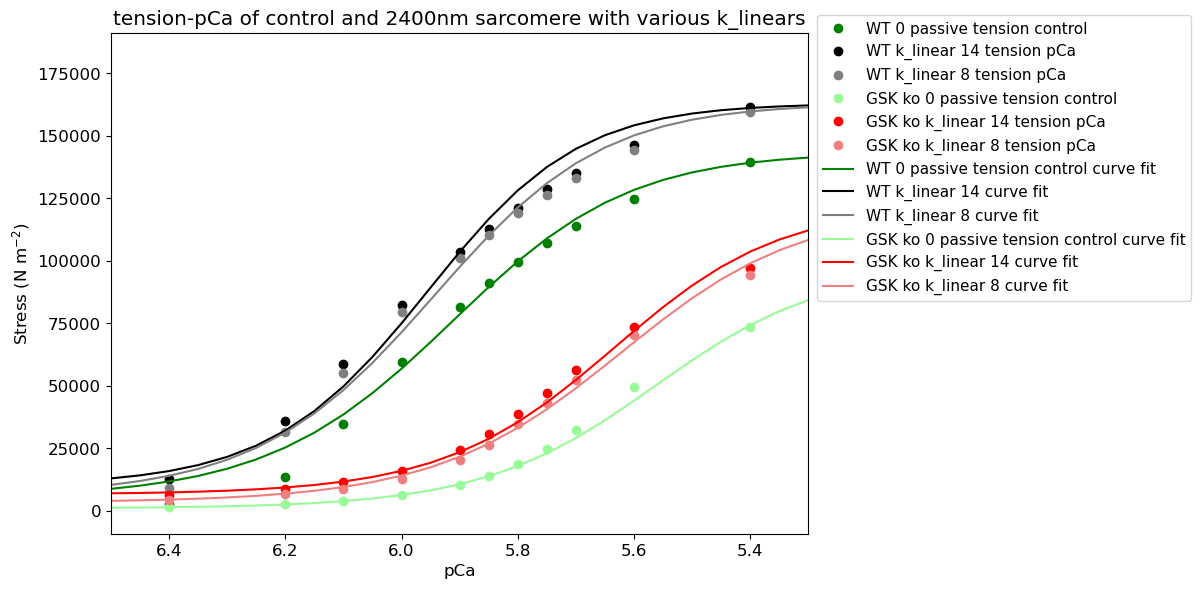

In [206]:
#MATLAB LDA tension-pCa of ALL slack 950 runs


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit

#x-tick values copied over from the defaults & added x-axis values in MATLAB
x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl1200'
wt=csv_file + '_kforce5_klin14_slack950.csv'
#print(wt)
#gsk=csv_file + '_kforce174_restored.csv' 
gsk=csv_file + '_kforce174_klin14_slack950.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))


gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
print(list_of_gsk)


fig,ax = plt.subplots()



plt.xlim(5.3,6.5)
plt.gca().invert_xaxis()

wt50=5.96
gsk50=5.64 #5.73
#gsk50=5.51

F=153000
#G=100000
G=114000



def hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)+10000



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-45))


def hill_GSK_function(G,Ca50,Ca,n):
    return (G+1000)/(1+(Ca50/Ca)**n)+6600 #-4000



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-39))

#WT PASSIVE 0 HILL FUNCTION#
csv_file='hsl950'
passive=csv_file + '_kforce5_klin14_slack950.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)

for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

P=138400
p50=5.92
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)+5000

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-38))




#GSK PASSIVE 0 HILL FUNCTION#
long_csv_file='hsl950'
long_passive=long_csv_file + '_kforce174_klin14_slack950.csv'
long_passive_obj = open(long_passive, 'r')
long_passive_csv = csv.reader(long_passive_obj)
#print(gsk_csv)
long_list_of_passive = list(long_passive_csv)
long_list_of_passive = long_list_of_passive[0]
#print(list_of_gsk)

for i in range(len(long_list_of_passive)):
    long_list_of_passive[i]=float(long_list_of_passive[i])
print(long_list_of_passive)

long_P=96000
long_p50=5.57
def hill_function(long_P,Ca50,Ca,n):
    return long_P/(1+(Ca50/Ca)**n)+1000

long_passive_sequence=[]
y=4.0
for i in range(0,1000):
    long_passive_sequence.append(y)
    y+=0.05

long_passive_line_items=[]
for Ca in long_passive_sequence:
    long_passive_line_items.append(hill_function(long_P,long_p50,Ca,-38))



long_csv='hsl1200'
#LONG STUFF
long_wt=long_csv + '_kforce5_klin8_slack950.csv'
#print(wt)
long_gsk=long_csv + '_kforce174_klin8_slack950.csv'
#wt_obj = open(wt, 'r')


long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
#print(type(list_of_wt[0]))


print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])


print(list_of_long_gsk)


long_wt50=5.95
long_gsk50=5.63

long_F=157000
long_G=117000


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)+6000

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)+3400

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-40))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-36))


plt.plot(x_values,list_of_passive,'go',label='WT 0 passive tension control')
plt.plot(x_values,list_of_wt,'ko',label='WT k_linear 14 tension pCa')
plt.plot(x_values,list_of_long_wt,'o',label='WT k_linear 8 tension pCa',color='gray')

plt.plot(x_values,long_list_of_passive,'o',label='GSK ko 0 passive tension control',color='palegreen')
plt.plot(x_values,list_of_gsk,'ro',label='GSK ko k_linear 14 tension pCa')
plt.plot(x_values,list_of_long_gsk,'o',label='GSK ko k_linear 8 tension pCa',color='lightcoral')


plt.plot(passive_sequence,passive_line_items,'g-',label='WT 0 passive tension control curve fit')
plt.plot(pCa_sequence,line_items,'k-',label='WT k_linear 14 curve fit')
plt.plot(long_pCa_sequence,long_line_items,'-',label='WT k_linear 8 curve fit',color='gray')

plt.plot(long_passive_sequence,long_passive_line_items,'-',label='GSK ko 0 passive tension control curve fit',color='palegreen')
plt.plot(GSK_sequence,gsk_line_items,'r-',label='GSK ko k_linear 14 curve fit')
plt.plot(long_GSK_sequence,long_gsk_line_items,'-',label='GSK ko k_linear 8 curve fit',color='lightcoral')

'''
plt.plot([6.45,6.090],[169000,169000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,170000,"\u0394 pCa$_{50}$ = 2400nm - 1900nm", fontsize=11)
plt.text(6.394,160000,text,fontsize=11)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.421,152000,gsk_text,fontsize=11)
'''
plt.legend()
plt.legend(bbox_to_anchor=(1.56,0.75),loc='center right',fontsize=11)

ax.figure.set_size_inches(9.0,6.5)
title="tension-pCa of control and 2400nm sarcomere with various k_linears"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='pCa_all_slack950.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300)
plt.show()


[3505.27512268891, 6305.30803960039, 8944.48488534397, 11533.0729749355, 16070.6650569085, 24382.1689916585, 30693.5374085065, 38941.2648436222, 47378.2646933983, 56575.5539656983, 73785.2731937968, 97346.7953831565, 127123.374683251]
[2.89694385034735, 2823.42888335648, 13685.0800559512, 34616.1311992923, 59646.7018108344, 81750.1438012293, 91260.8446467179, 99737.9030952121, 107246.172115362, 113866.725458332, 124791.056787197, 139621.247734719, 159517.581359306]
[2.89423764639342, 1495.6362346248, 2838.42260304338, 4114.96660357619, 6308.2591247069, 10434.2587569567, 13842.3917782032, 18966.1048401717, 24830.8536127552, 32359.2954372681, 49521.5922038007, 73409.6597600314, 103279.35419941]
[2006.53866969721, 9151.96453586988, 31401.9957731357, 55046.7848778354, 79540.6919173327, 101176.43168632, 110585.51185165, 119041.496158695, 126585.049296497, 133277.478117052, 144400.354378413, 159637.403712452, 180214.110146627]
[2004.43083112016, 4363.02670625932, 6604.01069245732, 8826.50836

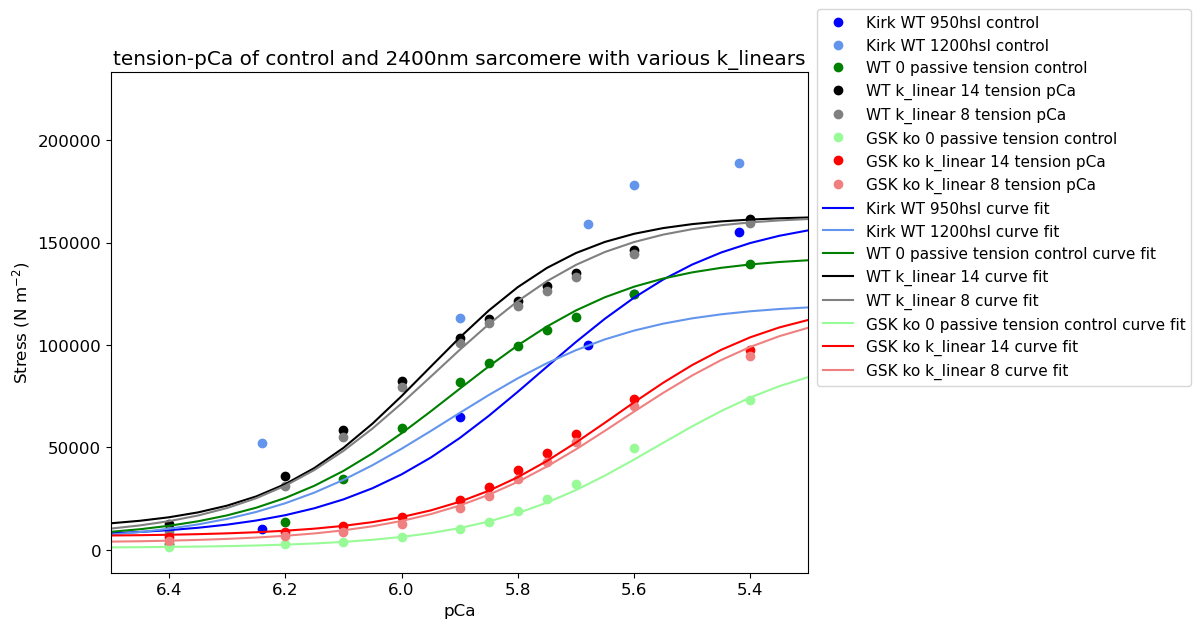

In [239]:
#MATLAB LDA tension-pCa of ALL slack 950 runs with Kirk data


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit

#x-tick values copied over from the defaults & added x-axis values in MATLAB
x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl1200'
wt=csv_file + '_kforce5_klin14_slack950.csv'
#print(wt)
#gsk=csv_file + '_kforce174_restored.csv' 
gsk=csv_file + '_kforce174_klin14_slack950.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))


gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
print(list_of_gsk)


fig,ax = plt.subplots()



plt.xlim(5.3,6.5)
plt.gca().invert_xaxis()

wt50=5.96
gsk50=5.64 #5.73
#gsk50=5.51

F=153000
#G=100000
G=114000



def hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)+10000



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-45))


def hill_GSK_function(G,Ca50,Ca,n):
    return (G+1000)/(1+(Ca50/Ca)**n)+6600 #-4000



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-39))

    
#WT PASSIVE 0 HILL FUNCTION#
csv_file='hsl950'
passive=csv_file + '_kforce5_klin14_slack950.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)

for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

P=138400
p50=5.92
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)+5000

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-38))




#GSK PASSIVE 0 HILL FUNCTION#
long_csv_file='hsl950'
long_passive=long_csv_file + '_kforce174_klin14_slack950.csv'
long_passive_obj = open(long_passive, 'r')
long_passive_csv = csv.reader(long_passive_obj)
#print(gsk_csv)
long_list_of_passive = list(long_passive_csv)
long_list_of_passive = long_list_of_passive[0]
#print(list_of_gsk)

for i in range(len(long_list_of_passive)):
    long_list_of_passive[i]=float(long_list_of_passive[i])
print(long_list_of_passive)

long_P=96000
long_p50=5.57
def hill_function(long_P,Ca50,Ca,n):
    return long_P/(1+(Ca50/Ca)**n)+1000

long_passive_sequence=[]
y=4.0
for i in range(0,1000):
    long_passive_sequence.append(y)
    y+=0.05

long_passive_line_items=[]
for Ca in long_passive_sequence:
    long_passive_line_items.append(hill_function(long_P,long_p50,Ca,-38))



long_csv='hsl1200'
#LONG STUFF
long_wt=long_csv + '_kforce5_klin8_slack950.csv'
#print(wt)
long_gsk=long_csv + '_kforce174_klin8_slack950.csv'
#wt_obj = open(wt, 'r')


long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
#print(type(list_of_wt[0]))


print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])


print(list_of_long_gsk)


long_wt50=5.95
long_gsk50=5.63

long_F=157000
long_G=117000


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)+6000

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)+3400

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-40))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-36))


#KIRK DATA
 
list_of_short_kirk = [10000,65000,100000,125000,155000,161000]
list_of_long_kirk = [52000,113000,159000,178000,189000,222000]



short_kirk_pCa50=5.77
long_kirk_pCa50=5.928

short_K=157000
long_K=117000
kirk_x_values=[6.24,5.9,5.68,5.6,5.42,4.4]

def short_kirk_hill_function(short_K,Ca50,Ca,n):
    return short_K/(1+(Ca50/Ca)**n)+6000

def long_kirk_hill_function(long_K,Ca50,Ca,n):
    return long_K/(1+(Ca50/Ca)**n)+3400

short_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    short_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

short_kirk_line_items=[]
for Ca in short_kirk_sequence:
    short_kirk_line_items.append(short_kirk_hill_function(short_K,short_kirk_pCa50,Ca,-36))

long_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    long_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_kirk_line_items=[]
for Ca in long_kirk_sequence:
    long_kirk_line_items.append(long_kirk_hill_function(long_K,long_kirk_pCa50,Ca,-36))

plt.plot(kirk_x_values,list_of_short_kirk,'bo',label='Kirk WT 950hsl control')
plt.plot(kirk_x_values,list_of_long_kirk,'o',label='Kirk WT 1200hsl control',color='cornflowerblue')
plt.plot(x_values,list_of_passive,'go',label='WT 0 passive tension control')
plt.plot(x_values,list_of_wt,'ko',label='WT k_linear 14 tension pCa')
plt.plot(x_values,list_of_long_wt,'o',label='WT k_linear 8 tension pCa',color='gray')

plt.plot(x_values,long_list_of_passive,'o',label='GSK ko 0 passive tension control',color='palegreen')
plt.plot(x_values,list_of_gsk,'ro',label='GSK ko k_linear 14 tension pCa')
plt.plot(x_values,list_of_long_gsk,'o',label='GSK ko k_linear 8 tension pCa',color='lightcoral')

plt.plot(short_kirk_sequence,short_kirk_line_items,'b-',label='Kirk WT 950hsl curve fit')
plt.plot(long_kirk_sequence,long_kirk_line_items,'-',label='Kirk WT 1200hsl curve fit',color='cornflowerblue')
plt.plot(passive_sequence,passive_line_items,'g-',label='WT 0 passive tension control curve fit')
plt.plot(pCa_sequence,line_items,'k-',label='WT k_linear 14 curve fit')
plt.plot(long_pCa_sequence,long_line_items,'-',label='WT k_linear 8 curve fit',color='gray')

plt.plot(long_passive_sequence,long_passive_line_items,'-',label='GSK ko 0 passive tension control curve fit',color='palegreen')
plt.plot(GSK_sequence,gsk_line_items,'r-',label='GSK ko k_linear 14 curve fit')
plt.plot(long_GSK_sequence,long_gsk_line_items,'-',label='GSK ko k_linear 8 curve fit',color='lightcoral')

'''
plt.plot([6.45,6.090],[169000,169000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,170000,"\u0394 pCa$_{50}$ = 2400nm - 1900nm", fontsize=11)
plt.text(6.394,160000,text,fontsize=11)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.421,152000,gsk_text,fontsize=11)
'''
plt.legend()
plt.legend(bbox_to_anchor=(1.56,0.75),loc='center right',fontsize=11)

ax.figure.set_size_inches(9.0,6.5)
title="tension-pCa of 1900nm and 2300nm sarcomere with various k_linears"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='pCa_kirk_data.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300)
plt.show()


[-4010.06154665913, -3116.47625849716, -2410.27675828444, -1800.98468367707, -858.166033151623, 8070.92913496596, 42878.6553143419, 44719.098957173, 44937.4107915462]
['19596.82146', '24759.07356', '30931.57189', '38094.89525', '50938.49906', '42915.46138', '49511.14168', '72006.56473', '61884.12759', '65875.11589', '77112.40126', '78513.51412', '79692.64428']


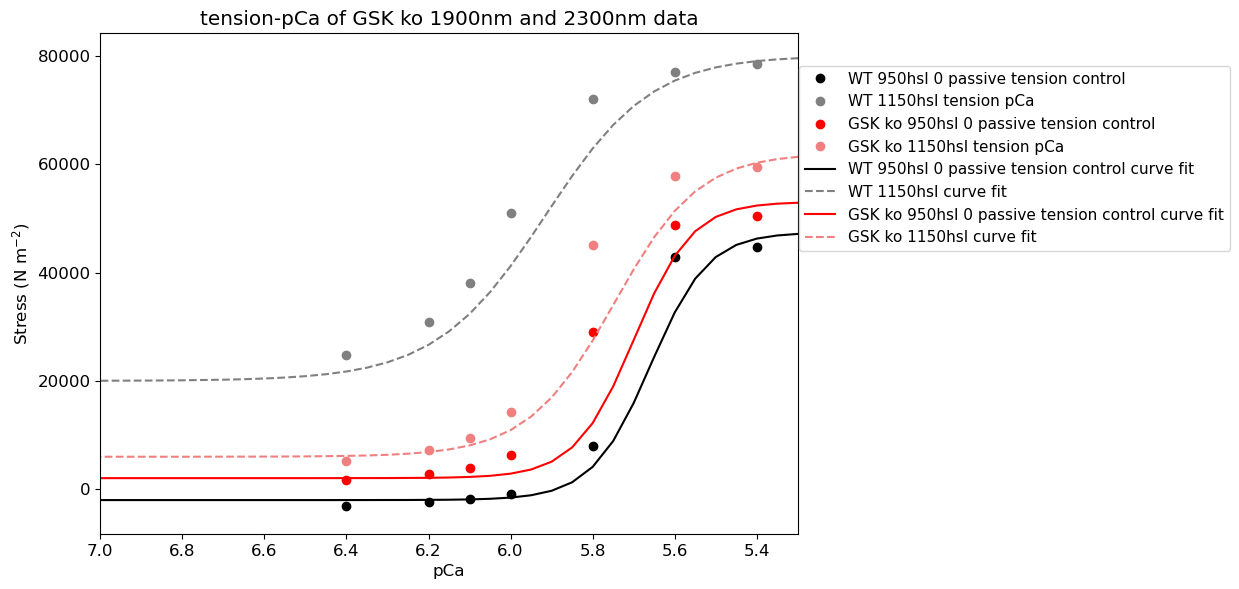

In [8]:
#MATLAB LDA tension-pCa of ALL slack 950 runs with Kirk data


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit

#x-tick values copied over from the defaults & added x-axis values in MATLAB
#x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]
x_values=[9,6.4,6.2,6.1,6,5.8,5.6,5.4,4.5]
values=[0,1,2,3,4,7,10,11,12]
import csv 


fig,ax = plt.subplots()



plt.xlim(5.3,7)
#plt.xlim(4.0,9.5)
plt.gca().invert_xaxis()

    
#WT PASSIVE 0 HILL FUNCTION#
csv_file='hsl950'
passive=csv_file + '_kp118_koff50.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)
'''
new_list_of_passive=[]
for value in values:
    new_list_of_passive.append(float(list_of_passive[value]))
print(new_list_of_passive)

P=49400
p50=5.66
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)-2000

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-80))




#GSK PASSIVE 0 HILL FUNCTION#
long_csv_file='hsl950'
long_passive=long_csv_file + '_kp14_koff50.csv'
long_passive_obj = open(long_passive, 'r')
long_passive_csv = csv.reader(long_passive_obj)
#print(gsk_csv)
long_list_of_passive = list(long_passive_csv)
long_list_of_passive = long_list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(long_list_of_passive)):
    long_list_of_passive[i]=float(long_list_of_passive[i])
print(long_list_of_passive)
'''
new_long_list_of_passive=[]
for value in values:
    new_long_list_of_passive.append(float(long_list_of_passive[value]))

long_P=51000
long_p50=5.70
def hill_function(long_P,Ca50,Ca,n):
    return long_P/(1+(Ca50/Ca)**n)+2050

long_passive_sequence=[]
y=4.0
for i in range(0,1000):
    long_passive_sequence.append(y)
    y+=0.05

long_passive_line_items=[]
for Ca in long_passive_sequence:
    long_passive_line_items.append(hill_function(long_P,long_p50,Ca,-80))




#HSL 1150 LONG STUFF

long_csv='hsl1150'
#LONG STUFF
long_wt=long_csv + '_kp118_koff50.csv'
#print(wt)
long_gsk=long_csv + '_kp14_koff50.csv'
#wt_obj = open(wt, 'r')


long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
'''
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
'''
new_long_wt=[]
for value in values:
    new_long_wt.append(float(list_of_long_wt[value]))
#print(type(list_of_wt[0]))


print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)
'''
for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])
'''
new_long_gsk=[]
for value in values:
    new_long_gsk.append(float(list_of_long_gsk[value]))



long_wt50=5.92
long_gsk50=5.75

long_F=60000
long_G=56000


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)+20000

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)+6000

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-45))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-55))


#KIRK DATA
kirk_x_values=[6.24,5.9,5.68,5.6,5.42,4.4]

#WT kirk
'''
list_of_short_kirk = [10000,65000,100000,125000,155000,161000]
list_of_long_kirk = [49000,113000,159000,178000,189000,222000]
short_kirk_pCa50=5.77
long_kirk_pCa50=5.928

short_K=170000
long_K=197000

def short_kirk_hill_function(short_K,Ca50,Ca,n):
    return short_K/(1+(Ca50/Ca)**n)+500

def long_kirk_hill_function(long_K,Ca50,Ca,n):
    return long_K/(1+(Ca50/Ca)**n)+7000
'''
#GSK ko kirk

list_of_short_kirk = [30000,69000,120000,148000,170000,183000]
list_of_long_kirk = [42000,93000,146000,169000,191000,224000]
short_kirk_pCa50=5.84
long_kirk_pCa50=5.85

short_K=178000
long_K=197000


def short_kirk_hill_function(short_K,Ca50,Ca,n):
    return short_K/(1+(Ca50/Ca)**n)+500

def long_kirk_hill_function(long_K,Ca50,Ca,n):
    return long_K/(1+(Ca50/Ca)**n)+7000

short_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    short_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

short_kirk_line_items=[]
for Ca in short_kirk_sequence:
    short_kirk_line_items.append(short_kirk_hill_function(short_K,short_kirk_pCa50,Ca,-36))

long_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    long_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_kirk_line_items=[]
for Ca in long_kirk_sequence:
    long_kirk_line_items.append(long_kirk_hill_function(long_K,long_kirk_pCa50,Ca,-35))

#plt.plot(kirk_x_values,list_of_short_kirk,'bo',label='Kirk WT 950hsl control')
#plt.plot(kirk_x_values,list_of_long_kirk,'o',label='Kirk WT 1150hsl',color='cornflowerblue')
plt.plot(x_values,new_list_of_passive,'ko',label='WT 950hsl 0 passive tension control')
plt.plot(x_values,new_long_wt,'o',label='WT 1150hsl tension pCa',color='gray')
#plt.plot(kirk_x_values,list_of_short_kirk,'go',label='Kirk GSKko 950hsl control')
#plt.plot(kirk_x_values,list_of_long_kirk,'o',label='Kirk GSK ko 1150hsl',color='limegreen')
plt.plot(x_values,new_long_list_of_passive,'ro',label='GSK ko 950hsl 0 passive tension control')
plt.plot(x_values,new_long_gsk,'o',label='GSK ko 1150hsl tension pCa',color='lightcoral')

#plt.plot(short_kirk_sequence,short_kirk_line_items,'b-',label='Kirk WT 950hsl curve fit')
#plt.plot(long_kirk_sequence,long_kirk_line_items,'--',label='Kirk WT 1150hsl curve fit',color='cornflowerblue')
plt.plot(passive_sequence,passive_line_items,'k-',label='WT 950hsl 0 passive tension control curve fit')
plt.plot(long_pCa_sequence,long_line_items,'--',label='WT 1150hsl curve fit',color='gray')
#plt.plot(short_kirk_sequence,short_kirk_line_items,'g-',label='Kirk GSKko 950hsl curve fit')
#plt.plot(long_kirk_sequence,long_kirk_line_items,'--',label='Kirk GSK ko 1150hsl curve fit',color='limegreen')
plt.plot(long_passive_sequence,long_passive_line_items,'r-',label='GSK ko 950hsl 0 passive tension control curve fit')
plt.plot(long_GSK_sequence,long_gsk_line_items,'--',label='GSK ko 1150hsl curve fit',color='lightcoral')

'''
plt.plot([6.45,6.090],[199000,199000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-p50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,200000,"\u0394 pCa$_{50}$ = 2300nm - 1900nm", fontsize=11)
plt.text(6.394,190000,text,fontsize=11)
gsk_delta50=round(long_gsk50-long_p50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.421,182000,gsk_text,fontsize=11)
'''
plt.legend()
plt.legend(bbox_to_anchor=(1.63,0.75),loc='center right',fontsize=11)

ax.figure.set_size_inches(9.0,6.5)
title="tension-pCa of GSK ko 1900nm and 2300nm data"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='pCa_Campbell_data.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=600)
plt.show()


[-4010.06154665913, -3116.47625849716, -2410.27675828444, -1800.98468367707, -858.166033151623, 8070.92913496596, 42878.6553143419, 44719.098957173, 44937.4107915462]
[19596.82146, 24759.07356, 30931.57189, 38094.89525, 50938.49906, 72006.56473, 77112.40126, 78513.51412, 79692.64428]
[0.0, 0.36423841059602646, 0.5960264900662252, 0.7615894039735099, 0.9602649006622517, 1.0]
[0.0, 0.3588235294117647, 0.6294117647058823, 0.7411764705882353, 0.8058823529411765, 1.0]


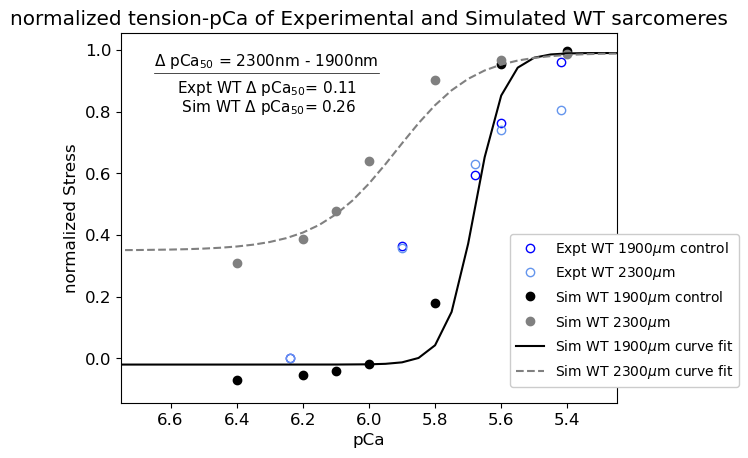

'/Users/alecloftus/Desktop/ABLIM_CG_Extended_Analyses/tension_pCa'

In [38]:
#Normalized MATLAB LDA tension-pCa KIRK data
#DATA DISCUSSION AVAILABLE in Campbell_values_kirk_comparison.xlsx

import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit


#x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]
modified_x_values=[9,6.4,6.2,6.1,6,5.8,5.6,5.4,4.5]
values=[0,1,2,3,4,7,10,11,12]

import csv 
    
#WT PASSIVE 0 HILL FUNCTION#
csv_file='hsl950'
#passive=csv_file + '_kforce5_klin14_slack950.csv'
passive=csv_file + '_kp118_koff50.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

normalized_passive=[]
for i in range(len(list_of_passive)):
    normalized_passive.append(list_of_passive[i]/max(list_of_passive))
'''
new_list_of_passive=[]
for value in values:
    new_list_of_passive.append(float(list_of_passive[value]))
print(new_list_of_passive)

#min_val = min(new_list_of_passive)
#max_val = max(new_list_of_passive)
#normalized_passive = [(val - min_val) / (max_val - min_val) for val in new_list_of_passive]
#print(normalized_passive)
normalized_passive=[]
for i in range(len(new_list_of_passive)):
    normalized_passive.append(new_list_of_passive[i]/max(new_list_of_passive))

P=1.01
p50=5.68
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)-0.02

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-130))




#WT 1150hsl length HILL FUNCTION#
long_csv_file='hsl1150'
#long_passive=long_csv_file + '_kforce5_klin14_slack950.csv'
long_passive=long_csv_file + '_kp118_koff50.csv'
long_passive_obj = open(long_passive, 'r')
long_passive_csv = csv.reader(long_passive_obj)
#print(gsk_csv)
long_list_of_passive = list(long_passive_csv)
long_list_of_passive = long_list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(long_list_of_passive)):
    long_list_of_passive[i]=float(long_list_of_passive[i])
#print(long_list_of_passive)

normalized_long_passive=[]
for i in range(len(long_list_of_passive)):
    normalized_long_passive.append(long_list_of_passive[i]/max(long_list_of_passive))
'''


new_long_list_of_passive=[]
for value in values:
    new_long_list_of_passive.append(float(long_list_of_passive[value]))
print(new_long_list_of_passive)

#min_val = min(new_long_list_of_passive)
#max_val = max(new_long_list_of_passive)
#normalized_long_passive = [(val - min_val) / (max_val - min_val) for val in new_long_list_of_passive]
#print(normalized_long_passive)

normalized_long_passive=[]
for i in range(len(new_long_list_of_passive)):
    normalized_long_passive.append(new_long_list_of_passive[i]/max(new_long_list_of_passive))

long_P=0.64
long_p50=5.92

def hill_function(long_P,Ca50,Ca,n):
    return long_P/(1+(Ca50/Ca)**n)+0.35

long_passive_sequence=[]
y=4.0
for i in range(0,1000):
    long_passive_sequence.append(y)
    y+=0.05

long_passive_line_items=[]
for Ca in long_passive_sequence:
    long_passive_line_items.append(hill_function(long_P,long_p50,Ca,-50))







#KIRK DATA
 
list_of_short_kirk = [10000,65000,100000,125000,155000,161000]
list_of_long_kirk = [52000,113000,159000,178000,192000,205000]

min_val = min(list_of_short_kirk)
max_val = max(list_of_short_kirk)
normalized_short_kirk = [(val - min_val) / (max_val - min_val) for val in list_of_short_kirk]

#normalized_short_kirk=[]
#for i in range(len(list_of_short_kirk)):
#    normalized_short_kirk.append(list_of_short_kirk[i]/max(list_of_short_kirk))

long_min_val = min(list_of_long_kirk)
long_max_val = max(list_of_long_kirk)
normalized_long_kirk = [(val - long_min_val) / (long_max_val - long_min_val) for val in list_of_long_kirk]
#normalized_long_kirk=[]
#for i in range(len(list_of_long_kirk)):
#    normalized_long_kirk.append(list_of_long_kirk[i]/max(list_of_long_kirk))

print(normalized_short_kirk)
print(normalized_long_kirk)

short_kirk_pCa50=5.75
long_kirk_pCa50=5.86

short_K=0.97
long_K=0.90
kirk_x_values=[6.24,5.9,5.68,5.6,5.42,4.4]

def short_kirk_hill_function(short_K,Ca50,Ca,n):
    return short_K/(1+(Ca50/Ca)**n)+0.04

def long_kirk_hill_function(long_K,Ca50,Ca,n):
    return long_K/(1+(Ca50/Ca)**n)+0.08
short_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    short_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

short_kirk_line_items=[]
for Ca in short_kirk_sequence:
    short_kirk_line_items.append(short_kirk_hill_function(short_K,short_kirk_pCa50,Ca,-38))

long_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    long_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_kirk_line_items=[]
for Ca in long_kirk_sequence:
    long_kirk_line_items.append(long_kirk_hill_function(long_K,long_kirk_pCa50,Ca,-28))

plt.plot(kirk_x_values,normalized_short_kirk,'bo',label='Expt WT 1900$\mu$m control',markerfacecolor='none')
plt.plot(kirk_x_values,normalized_long_kirk,'o',label='Expt WT 2300$\mu$m',color='cornflowerblue',markerfacecolor='none')
#plt.plot(short_kirk_sequence,short_kirk_line_items,'b-',label='Kirk WT 950hsl curve fit')
#plt.plot(long_kirk_sequence,long_kirk_line_items,'--',label='Kirk WT 1150hsl curve fit',color='cornflowerblue')
'''
plt.plot(x_values,normalized_passive,'ko',label='WT 950hsl 0 passive tension control')
plt.plot(x_values,normalized_long_passive,'o',label='WT 1150hsl', color='gray')
'''
plt.plot(modified_x_values,normalized_passive,'ko',label='Sim WT 1900$\mu$m control')
plt.plot(modified_x_values,normalized_long_passive,'o',label='Sim WT 2300$\mu$m', color='gray')
plt.plot(passive_sequence,passive_line_items,'k-',label='Sim WT 1900$\mu$m curve fit')
plt.plot(long_passive_sequence,long_passive_line_items,'--',label='Sim WT 2300$\mu$m curve fit',color='gray')


plt.legend()
plt.legend(bbox_to_anchor=(1.26,0.25),loc='center right',fontsize=10,framealpha=1.0)
plt.xlim(6.75,5.25)
#plt.xlim(9.2,4.5)

title="normalized tension-pCa of Experimental and Simulated WT sarcomeres"
plt.title(title)

plt.plot([6.65,5.97],[0.925,0.925],color='black',linewidth=0.5)
exp_delta50=round(long_kirk_pCa50-short_kirk_pCa50,3)
exp_text="Expt WT \u0394 pCa$_{50}$= "+str(exp_delta50)
plt.text(6.58,0.86,exp_text,fontsize=11)
wt_delta50=round(long_p50-p50+0.02,3)
wt_text=" Sim WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.58,0.80,wt_text,fontsize=11)
plt.text(6.65,0.95,"\u0394 pCa$_{50}$ = 2300nm - 1900nm", fontsize=11)



plt.xlabel("pCa")
plt.ylabel('normalized Stress')
ax.figure.set_size_inches(10.0,5.5)
name='pCa_normal_WT.png'
os.chdir(path)
#plt.gcf().savefig(name,dpi=600,bbox_inches='tight')
plt.show()
os.getcwd()

In [60]:
no_tension_p= [2.209593804,1176.671209,2384.548261,3702.232578,6452.152346,5085.695632,6977.551078,
               33321.29134,14927.01046,21694.711,51541.5514,54260.80838,56429.37602]
tension_p= [19596.82146,24759.07356,30931.57189,38094.89525,50938.49906,42915.46138,49511.14168,
            72006.56473,61884.12759,65875.11589,77112.40126,78513.51412,79692.64428]
tension100= [11806.34791,15395.01412,19505.58493,24323.53591,34256.04723,28239.45053,33816.98174,
             61280.21042,47550.84555,52930.41852,67216.79946,68992.55843,70746.80217]
import statistics as ss
diff=[]
for i in range(len(no_tension_p)):
    difference = tension100[i] - tension_p[i]
    diff.append(difference)

print(diff)
print(ss.mean(diff))

[-7790.473549999999, -9364.05944, -11425.986959999998, -13771.359340000003, -16682.451830000005, -14676.010850000002, -15694.159939999998, -10726.354309999995, -14333.282039999998, -12944.697370000002, -9895.601800000004, -9520.955690000003, -8945.842109999998]
-11982.40271


[-4010.06154665913, -3116.47625849716, -2410.27675828444, -1800.98468367707, -858.166033151623, 8070.92913496596, 42878.6553143419, 44719.098957173, 44937.4107915462]
[0.0, 0.01825600476338577, 0.03268370585759539, 0.04513158202977914, 0.06439342754472194, 0.2468154146582034, 0.9579394935252382, 0.9955398752183817, 1.0]
[19596.82146, 24759.07356, 30931.57189, 38094.89525, 50938.49906, 72006.56473, 77112.40126, 78513.51412, 79692.64428]
[0.0, 0.08590034810675719, 0.18861128607806957, 0.30780964336582495, 0.5215283879858857, 0.8721029317957512, 0.9570645196467584, 0.9803791660606472, 1.0]
[0.0, 0.36423841059602646, 0.5960264900662252, 0.7615894039735099, 0.9602649006622517, 1.0]
[0.0, 0.40397350993377484, 0.7086092715231788, 0.8344370860927153, 0.9205298013245033, 1.0]


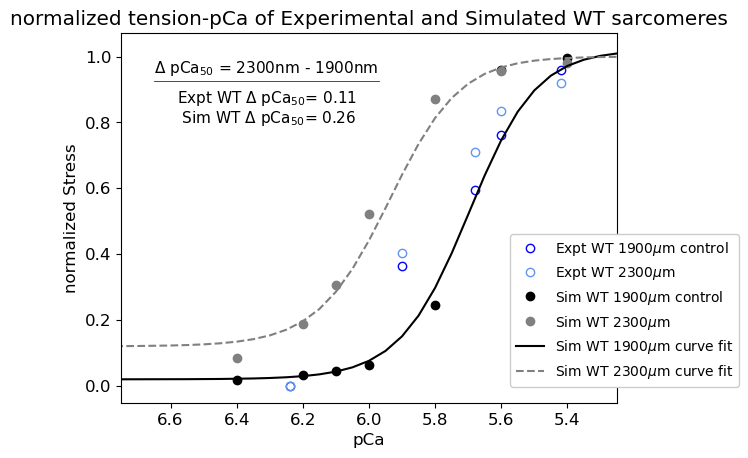

'/Users/alecloftus/Desktop/ABLIM_CG_Extended_Analyses/tension_pCa'

In [65]:
#Normalized MATLAB LDA tension-pCa KIRK data
#DATA DISCUSSION AVAILABLE in Campbell_values_kirk_comparison.xlsx

import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit


#x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]
modified_x_values=[9,6.4,6.2,6.1,6,5.8,5.6,5.4,4.5]
values=[0,1,2,3,4,7,10,11,12]

import csv 
    
#WT PASSIVE 0 HILL FUNCTION#
csv_file='hsl950'
#passive=csv_file + '_kforce5_klin14_slack950.csv'
#passive=csv_file + '_Campbell_tension0.csv'
passive=csv_file + '_kp118_koff50.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

normalized_passive=[]
for i in range(len(list_of_passive)):
    normalized_passive.append(list_of_passive[i]/max(list_of_passive))
'''
new_list_of_passive=[]
for value in values:
    new_list_of_passive.append(float(list_of_passive[value]))
print(new_list_of_passive)

min_val = min(new_list_of_passive)
max_val = max(new_list_of_passive)
normalized_passive = [(val - min_val) / (max_val - min_val) for val in new_list_of_passive]
print(normalized_passive)
#normalized_passive=[]
#for i in range(len(new_list_of_passive)):
#    normalized_passive.append(new_list_of_passive[i]/max(new_list_of_passive))

P=1.0
p50=5.70
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)+0.02

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-55))




#WT 1150hsl length HILL FUNCTION#
long_csv_file='hsl1150'
#long_passive=long_csv_file + '_kforce5_klin14_slack950.csv'
#long_passive=long_csv_file + '_Campbell_tension0.csv'
long_passive=long_csv_file + '_kp118_koff50.csv'
long_passive_obj = open(long_passive, 'r')
long_passive_csv = csv.reader(long_passive_obj)
#print(gsk_csv)
long_list_of_passive = list(long_passive_csv)
long_list_of_passive = long_list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(long_list_of_passive)):
    long_list_of_passive[i]=float(long_list_of_passive[i])
#print(long_list_of_passive)

normalized_long_passive=[]
for i in range(len(long_list_of_passive)):
    normalized_long_passive.append(long_list_of_passive[i]/max(long_list_of_passive))
'''


new_long_list_of_passive=[]
for value in values:
    new_long_list_of_passive.append(float(long_list_of_passive[value]))
print(new_long_list_of_passive)

min_val = min(new_long_list_of_passive)
max_val = max(new_long_list_of_passive)
normalized_long_passive = [(val - min_val) / (max_val - min_val) for val in new_long_list_of_passive]
print(normalized_long_passive)

#normalized_long_passive=[]
#for i in range(len(new_long_list_of_passive)):
#    normalized_long_passive.append(new_long_list_of_passive[i]/max(new_long_list_of_passive))

long_P=0.88
long_p50=5.94

def hill_function(long_P,Ca50,Ca,n):
    return long_P/(1+(Ca50/Ca)**n)+0.12

long_passive_sequence=[]
y=4.0
for i in range(0,1000):
    long_passive_sequence.append(y)
    y+=0.05

long_passive_line_items=[]
for Ca in long_passive_sequence:
    long_passive_line_items.append(hill_function(long_P,long_p50,Ca,-55))



#KIRK DATA
 
list_of_short_kirk = [10000,65000,100000,125000,155000,161000]
list_of_long_kirk = [52000,113000,159000,178000,191000,203000]

min_val = min(list_of_short_kirk)
max_val = max(list_of_short_kirk)
normalized_short_kirk = [(val - min_val) / (max_val - min_val) for val in list_of_short_kirk]

#normalized_short_kirk=[]
#for i in range(len(list_of_short_kirk)):
#    normalized_short_kirk.append(list_of_short_kirk[i]/max(list_of_short_kirk))

long_min_val = min(list_of_long_kirk)
long_max_val = max(list_of_long_kirk)
normalized_long_kirk = [(val - long_min_val) / (long_max_val - long_min_val) for val in list_of_long_kirk]
#normalized_long_kirk=[]
#for i in range(len(list_of_long_kirk)):
#    normalized_long_kirk.append(list_of_long_kirk[i]/max(list_of_long_kirk))

print(normalized_short_kirk)
print(normalized_long_kirk)

short_kirk_pCa50=5.75
long_kirk_pCa50=5.86

short_K=0.97
long_K=0.90
kirk_x_values=[6.24,5.9,5.68,5.6,5.42,4.4]

def short_kirk_hill_function(short_K,Ca50,Ca,n):
    return short_K/(1+(Ca50/Ca)**n)+0.04

def long_kirk_hill_function(long_K,Ca50,Ca,n):
    return long_K/(1+(Ca50/Ca)**n)+0.08
short_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    short_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

short_kirk_line_items=[]
for Ca in short_kirk_sequence:
    short_kirk_line_items.append(short_kirk_hill_function(short_K,short_kirk_pCa50,Ca,-38))

long_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    long_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_kirk_line_items=[]
for Ca in long_kirk_sequence:
    long_kirk_line_items.append(long_kirk_hill_function(long_K,long_kirk_pCa50,Ca,-28))

plt.plot(kirk_x_values,normalized_short_kirk,'bo',label='Expt WT 1900$\mu$m control',markerfacecolor='none')
plt.plot(kirk_x_values,normalized_long_kirk,'o',label='Expt WT 2300$\mu$m',color='cornflowerblue',markerfacecolor='none')
#plt.plot(short_kirk_sequence,short_kirk_line_items,'b-',label='Kirk WT 950hsl curve fit')
#plt.plot(long_kirk_sequence,long_kirk_line_items,'--',label='Kirk WT 1150hsl curve fit',color='cornflowerblue')
'''
plt.plot(x_values,normalized_passive,'ko',label='WT 950hsl 0 passive tension control')
plt.plot(x_values,normalized_long_passive,'o',label='WT 1150hsl', color='gray')
'''
plt.plot(modified_x_values,normalized_passive,'ko',label='Sim WT 1900$\mu$m control')
plt.plot(modified_x_values,normalized_long_passive,'o',label='Sim WT 2300$\mu$m', color='gray')
plt.plot(passive_sequence,passive_line_items,'k-',label='Sim WT 1900$\mu$m curve fit')
plt.plot(long_passive_sequence,long_passive_line_items,'--',label='Sim WT 2300$\mu$m curve fit',color='gray')


plt.legend()
plt.legend(bbox_to_anchor=(1.26,0.25),loc='center right',fontsize=10,framealpha=1.0)
plt.xlim(6.75,5.25)
#plt.xlim(9.2,4.5)

title="normalized tension-pCa of Experimental and Simulated WT sarcomeres"
plt.title(title)

plt.plot([6.65,5.97],[0.925,0.925],color='black',linewidth=0.5)
exp_delta50=round(long_kirk_pCa50-short_kirk_pCa50,3)
exp_text="Expt WT \u0394 pCa$_{50}$= "+str(exp_delta50)
plt.text(6.58,0.86,exp_text,fontsize=11)
wt_delta50=round(long_p50-p50+0.02,3)
wt_text=" Sim WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.58,0.80,wt_text,fontsize=11)
plt.text(6.65,0.95,"\u0394 pCa$_{50}$ = 2300nm - 1900nm", fontsize=11)



plt.xlabel("pCa")
plt.ylabel('normalized Stress')
ax.figure.set_size_inches(10.0,5.5)
name='pCa_normalized_WT.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=600,bbox_inches='tight')
plt.show()
os.getcwd()

[534.112474296068, 1641.92695949592, 2754.43031325366, 3942.95807447484, 6357.79520750928, 28968.3418097125, 48879.8317708953, 50517.5363460457, 51278.1386837437]
[0.0, 0.032418235961911776, 0.06698170505061253, 0.1059010374477259, 0.18947928765657376, 0.7293395335521037, 0.9525981086032004, 0.9813910841109468, 1.0]
[0.0, 0.2549019607843137, 0.5882352941176471, 0.7712418300653595, 0.9150326797385621, 1.0]
[0.0, 0.2640449438202247, 0.5617977528089888, 0.7134831460674157, 0.8426966292134831, 1.0]


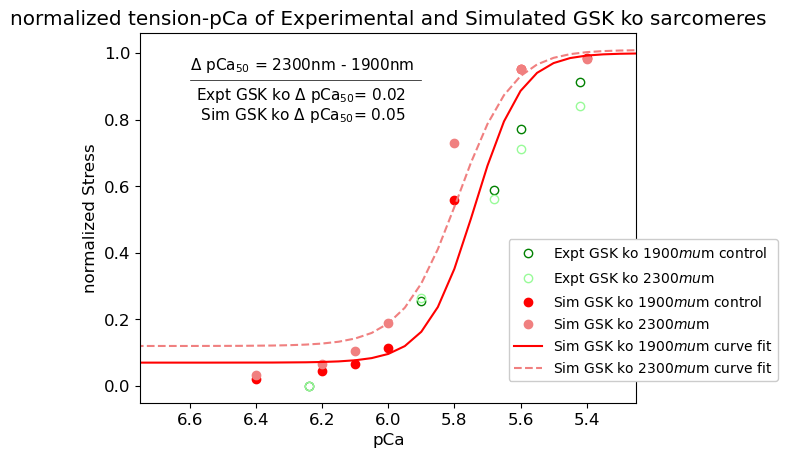

'/Users/alecloftus/Desktop/ABLIM_CG_Extended_Analyses/tension_pCa'

In [11]:
#Normalized MATLAB LDA tension-pCa KIRK data


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit


#x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]
modified_x_values=[9,6.4,6.2,6.1,6,5.8,5.6,5.4,4.5]
values=[0,1,2,3,4,7,10,11,12]

import csv 
    
#WT PASSIVE 0 HILL FUNCTION#
csv_file='hsl950'
passive=csv_file + '_kp14_koff50.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

normalized_passive=[]
for i in range(len(list_of_passive)):
    normalized_passive.append(list_of_passive[i]/max(list_of_passive))

'''
new_list_of_passive=[]
for value in values:
    new_list_of_passive.append(float(list_of_passive[value]))
print(new_list_of_passive)

min_val = min(new_list_of_passive)
max_val = max(new_list_of_passive)
normalized_passive = [(val - min_val) / (max_val - min_val) for val in new_list_of_passive]

#normalized_passive=[]
#for i in range(len(new_list_of_passive)):
#    normalized_passive.append(new_list_of_passive[i]/max(new_list_of_passive))



P=0.93
p50=5.74
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)+0.07

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-80))




#GSK ko 1150hsl length HILL FUNCTION#
long_csv_file='hsl1150'
long_passive=long_csv_file + '_kp14_koff50.csv'
long_passive_obj = open(long_passive, 'r')
long_passive_csv = csv.reader(long_passive_obj)
#print(gsk_csv)
long_list_of_passive = list(long_passive_csv)
long_list_of_passive = long_list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(long_list_of_passive)):
    long_list_of_passive[i]=float(long_list_of_passive[i])
#print(long_list_of_passive)

normalized_long_passive=[]
for i in range(len(long_list_of_passive)):
    normalized_long_passive.append(long_list_of_passive[i]/max(long_list_of_passive))

'''
new_long_list_of_passive=[]
for value in values:
    new_long_list_of_passive.append(float(long_list_of_passive[value]))
#print(long_list_of_passive)

min_val = min(new_long_list_of_passive)
max_val = max(new_long_list_of_passive)
normalized_long_passive = [(val - min_val) / (max_val - min_val) for val in new_long_list_of_passive]
print(normalized_long_passive)

#normalized_long_passive=[]
#for i in range(len(new_long_list_of_passive)):
#    normalized_long_passive.append(new_long_list_of_passive[i]/max(new_long_list_of_passive))


long_P=0.89
long_p50=5.79
def hill_function(long_P,Ca50,Ca,n):
    return long_P/(1+(Ca50/Ca)**n)+0.12

long_passive_sequence=[]
y=4.0
for i in range(0,1000):
    long_passive_sequence.append(y)
    y+=0.05

long_passive_line_items=[]
for Ca in long_passive_sequence:
    long_passive_line_items.append(hill_function(long_P,long_p50,Ca,-70))



#KIRK GSK ko DATA
 
list_of_short_kirk = [30000,69000,120000,148000,170000,183000]
list_of_long_kirk = [46000,93000,146000,173000,196000,224000]

min_val = min(list_of_short_kirk)
max_val = max(list_of_short_kirk)
normalized_short_kirk = [(val - min_val) / (max_val - min_val) for val in list_of_short_kirk]

#normalized_short_kirk=[]
#for i in range(len(list_of_short_kirk)):
#    normalized_short_kirk.append(list_of_short_kirk[i]/max(list_of_short_kirk))

long_min_val = min(list_of_long_kirk)
long_max_val = max(list_of_long_kirk)
normalized_long_kirk = [(val - long_min_val) / (long_max_val - long_min_val) for val in list_of_long_kirk]

#normalized_long_kirk=[]
#for i in range(len(list_of_long_kirk)):
#    normalized_long_kirk.append(list_of_long_kirk[i]/max(list_of_long_kirk))

print(normalized_short_kirk)
print(normalized_long_kirk)

short_kirk_pCa50=5.84
long_kirk_pCa50=5.86

short_K=0.84
long_K=0.80
kirk_x_values=[6.24,5.9,5.68,5.6,5.42,4.4]

def short_kirk_hill_function(short_K,Ca50,Ca,n):
    return short_K/(1+(Ca50/Ca)**n)+0.1

def long_kirk_hill_function(long_K,Ca50,Ca,n):
    return long_K/(1+(Ca50/Ca)**n)+0.11
short_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    short_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

short_kirk_line_items=[]
for Ca in short_kirk_sequence:
    short_kirk_line_items.append(short_kirk_hill_function(short_K,short_kirk_pCa50,Ca,-42))

long_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    long_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_kirk_line_items=[]
for Ca in long_kirk_sequence:
    long_kirk_line_items.append(long_kirk_hill_function(long_K,long_kirk_pCa50,Ca,-40))

plt.plot(kirk_x_values,normalized_short_kirk,'go',label='Expt GSK ko 1900$\mu$m control',markerfacecolor='none')
plt.plot(kirk_x_values,normalized_long_kirk,'o',label='Expt GSK ko 2300$\mu$m',color='palegreen',markerfacecolor='none')
#plt.plot(short_kirk_sequence,short_kirk_line_items,'g-',label='Kirk GSK ko 950hsl curve fit')
#plt.plot(long_kirk_sequence,long_kirk_line_items,'--',label='Kirk GSK ko 1150hsl curve fit',color='palegreen')

plt.plot(modified_x_values,normalized_passive,'ro',label='Sim GSK ko 1900$\mu$m control')
plt.plot(modified_x_values,normalized_long_passive,'o',label='Sim GSK ko 2300$\mu$m', color='lightcoral')
'''
plt.plot(modified_x_values,normalized_passive,'ro',label='GSK ko 950hsl 0 passive tension control')
plt.plot(modified_x_values,normalized_long_passive,'o',label='GSK ko 1150hsl', color='lightcoral')
'''
plt.plot(passive_sequence,passive_line_items,'r-',label='Sim GSK ko 1900$\mu$m curve fit')
plt.plot(long_passive_sequence,long_passive_line_items,'--',label='Sim GSK ko 2300$\mu$m curve fit',color='lightcoral')

plt.legend()
plt.legend(bbox_to_anchor=(1.30,0.25),loc='center right',fontsize=10,framealpha=1.0)
plt.xlim(6.75,5.25)


plt.plot([6.6,5.9],[0.92,0.92],color='black',linewidth=0.5)

plt.text(6.6,0.95,"\u0394 pCa$_{50}$ = 2300nm - 1900nm", fontsize=11)
exp_delta50=round(long_kirk_pCa50-short_kirk_pCa50,3)
exp_text="Expt GSK ko \u0394 pCa$_{50}$= "+str(exp_delta50)
plt.text(6.58,0.86,exp_text,fontsize=11)
gsk_delta50=round(long_p50-p50,3)
gsk_text=" Sim GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.58,0.80,gsk_text,fontsize=11)

title="normalized tension-pCa of Experimental and Simulated GSK ko sarcomeres"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('normalized Stress')
ax.figure.set_size_inches(10.0,5.5)
name='pCa_normal_GSKko.png'
os.chdir(path)
#plt.gcf().savefig(name,dpi=600,bbox_inches='tight')
plt.show()
os.getcwd()

[534.112474296068, 1641.92695949592, 2754.43031325366, 3942.95807447484, 6357.79520750928, 28968.3418097125, 48879.8317708953, 50517.5363460457, 51278.1386837437]
[0.0, 0.032418235961911776, 0.06698170505061253, 0.1059010374477259, 0.18947928765657376, 0.7293395335521037, 0.9525981086032004, 0.9813910841109468, 1.0]
[0.0, 0.2549019607843137, 0.5882352941176471, 0.7712418300653595, 0.9150326797385621, 1.0]
[0.0, 0.2640449438202247, 0.5617977528089888, 0.7134831460674157, 0.8426966292134831, 1.0]


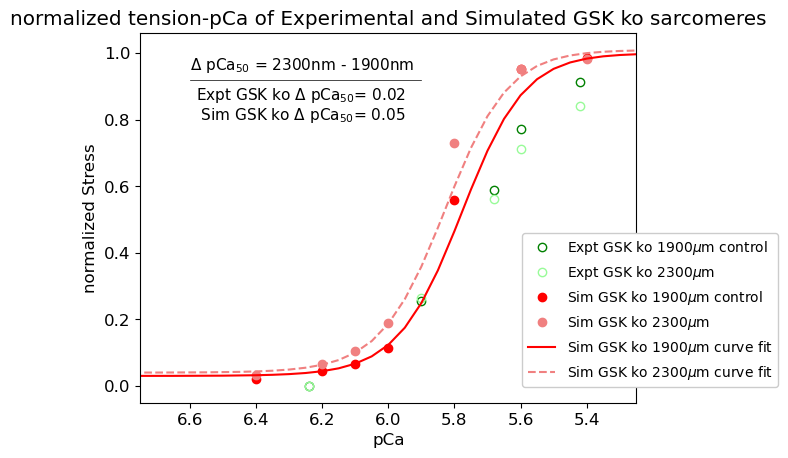

'/Users/alecloftus/Desktop/ABLIM_CG_Extended_Analyses/tension_pCa'

In [63]:
#Normalized MATLAB LDA tension-pCa KIRK data


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit


#x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]
modified_x_values=[9,6.4,6.2,6.1,6,5.8,5.6,5.4,4.5]
values=[0,1,2,3,4,7,10,11,12]

import csv 
    
#WT PASSIVE 0 HILL FUNCTION#
csv_file='hsl950'
passive=csv_file + '_kp14_koff50.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

normalized_passive=[]
for i in range(len(list_of_passive)):
    normalized_passive.append(list_of_passive[i]/max(list_of_passive))

'''
new_list_of_passive=[]
for value in values:
    new_list_of_passive.append(float(list_of_passive[value]))
print(new_list_of_passive)

min_val = min(new_list_of_passive)
max_val = max(new_list_of_passive)
normalized_passive = [(val - min_val) / (max_val - min_val) for val in new_list_of_passive]

#normalized_passive=[]
#for i in range(len(new_list_of_passive)):
#    normalized_passive.append(new_list_of_passive[i]/max(new_list_of_passive))



P=0.97
p50=5.78
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)+0.03

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-60))




#GSK ko 1150hsl length HILL FUNCTION#
long_csv_file='hsl1150'
long_passive=long_csv_file + '_kp14_koff50.csv'
long_passive_obj = open(long_passive, 'r')
long_passive_csv = csv.reader(long_passive_obj)
#print(gsk_csv)
long_list_of_passive = list(long_passive_csv)
long_list_of_passive = long_list_of_passive[0]
#print(list_of_gsk)
'''
for i in range(len(long_list_of_passive)):
    long_list_of_passive[i]=float(long_list_of_passive[i])
#print(long_list_of_passive)

normalized_long_passive=[]
for i in range(len(long_list_of_passive)):
    normalized_long_passive.append(long_list_of_passive[i]/max(long_list_of_passive))

'''
new_long_list_of_passive=[]
for value in values:
    new_long_list_of_passive.append(float(long_list_of_passive[value]))
#print(long_list_of_passive)

min_val = min(new_long_list_of_passive)
max_val = max(new_long_list_of_passive)
normalized_long_passive = [(val - min_val) / (max_val - min_val) for val in new_long_list_of_passive]
print(normalized_long_passive)

#normalized_long_passive=[]
#for i in range(len(new_long_list_of_passive)):
#    normalized_long_passive.append(new_long_list_of_passive[i]/max(new_long_list_of_passive))


long_P=0.97
long_p50=5.83
def hill_function(long_P,Ca50,Ca,n):
    return long_P/(1+(Ca50/Ca)**n)+0.04

long_passive_sequence=[]
y=4.0
for i in range(0,1000):
    long_passive_sequence.append(y)
    y+=0.05

long_passive_line_items=[]
for Ca in long_passive_sequence:
    long_passive_line_items.append(hill_function(long_P,long_p50,Ca,-60))



#KIRK GSK ko DATA
 
list_of_short_kirk = [30000,69000,120000,148000,170000,183000]
list_of_long_kirk = [46000,93000,146000,173000,196000,224000]

min_val = min(list_of_short_kirk)
max_val = max(list_of_short_kirk)
normalized_short_kirk = [(val - min_val) / (max_val - min_val) for val in list_of_short_kirk]

#normalized_short_kirk=[]
#for i in range(len(list_of_short_kirk)):
#    normalized_short_kirk.append(list_of_short_kirk[i]/max(list_of_short_kirk))

long_min_val = min(list_of_long_kirk)
long_max_val = max(list_of_long_kirk)
normalized_long_kirk = [(val - long_min_val) / (long_max_val - long_min_val) for val in list_of_long_kirk]

#normalized_long_kirk=[]
#for i in range(len(list_of_long_kirk)):
#    normalized_long_kirk.append(list_of_long_kirk[i]/max(list_of_long_kirk))

print(normalized_short_kirk)
print(normalized_long_kirk)

short_kirk_pCa50=5.84
long_kirk_pCa50=5.86

short_K=0.84
long_K=0.80
kirk_x_values=[6.24,5.9,5.68,5.6,5.42,4.4]

def short_kirk_hill_function(short_K,Ca50,Ca,n):
    return short_K/(1+(Ca50/Ca)**n)+0.1

def long_kirk_hill_function(long_K,Ca50,Ca,n):
    return long_K/(1+(Ca50/Ca)**n)+0.11
short_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    short_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

short_kirk_line_items=[]
for Ca in short_kirk_sequence:
    short_kirk_line_items.append(short_kirk_hill_function(short_K,short_kirk_pCa50,Ca,-42))

long_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    long_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_kirk_line_items=[]
for Ca in long_kirk_sequence:
    long_kirk_line_items.append(long_kirk_hill_function(long_K,long_kirk_pCa50,Ca,-40))

plt.plot(kirk_x_values,normalized_short_kirk,'go',label='Expt GSK ko 1900$\mu$m control',markerfacecolor='none')
plt.plot(kirk_x_values,normalized_long_kirk,'o',label='Expt GSK ko 2300$\mu$m',color='palegreen',markerfacecolor='none')
#plt.plot(short_kirk_sequence,short_kirk_line_items,'g-',label='Kirk GSK ko 950hsl curve fit')
#plt.plot(long_kirk_sequence,long_kirk_line_items,'--',label='Kirk GSK ko 1150hsl curve fit',color='palegreen')

plt.plot(modified_x_values,normalized_passive,'ro',label='Sim GSK ko 1900$\mu$m control')
plt.plot(modified_x_values,normalized_long_passive,'o',label='Sim GSK ko 2300$\mu$m', color='lightcoral')
'''
plt.plot(modified_x_values,normalized_passive,'ro',label='GSK ko 950hsl 0 passive tension control')
plt.plot(modified_x_values,normalized_long_passive,'o',label='GSK ko 1150hsl', color='lightcoral')
'''
plt.plot(passive_sequence,passive_line_items,'r-',label='Sim GSK ko 1900$\mu$m curve fit')
plt.plot(long_passive_sequence,long_passive_line_items,'--',label='Sim GSK ko 2300$\mu$m curve fit',color='lightcoral')

plt.legend()
plt.legend(bbox_to_anchor=(1.30,0.25),loc='center right',fontsize=10,framealpha=1.0)
plt.xlim(6.75,5.25)


plt.plot([6.6,5.9],[0.92,0.92],color='black',linewidth=0.5)

plt.text(6.6,0.95,"\u0394 pCa$_{50}$ = 2300nm - 1900nm", fontsize=11)
exp_delta50=round(long_kirk_pCa50-short_kirk_pCa50,3)
exp_text="Expt GSK ko \u0394 pCa$_{50}$= "+str(exp_delta50)
plt.text(6.58,0.86,exp_text,fontsize=11)
gsk_delta50=round(long_p50-p50,3)
gsk_text=" Sim GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.58,0.80,gsk_text,fontsize=11)

title="normalized tension-pCa of Experimental and Simulated GSK ko sarcomeres"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('normalized Stress')
ax.figure.set_size_inches(10.0,5.5)
name='pCa_normalized_GSKko.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=600,bbox_inches='tight')
plt.show()
os.getcwd()

[2.89694385034735, 2823.42888335648, 13685.0800559512, 34616.1311992923, 59646.7018108344, 81750.1438012293, 91260.8446467179, 99737.9030952121, 107246.172115362, 113866.725458332, 124791.056787197, 139621.247734719, 159517.581359306]
[0.062111801242236024, 0.40372670807453415, 0.6211180124223602, 0.7763975155279503, 0.9627329192546584, 1.0]
[0.23423423423423423, 0.509009009009009, 0.7162162162162162, 0.8018018018018018, 0.8513513513513513, 1.0]


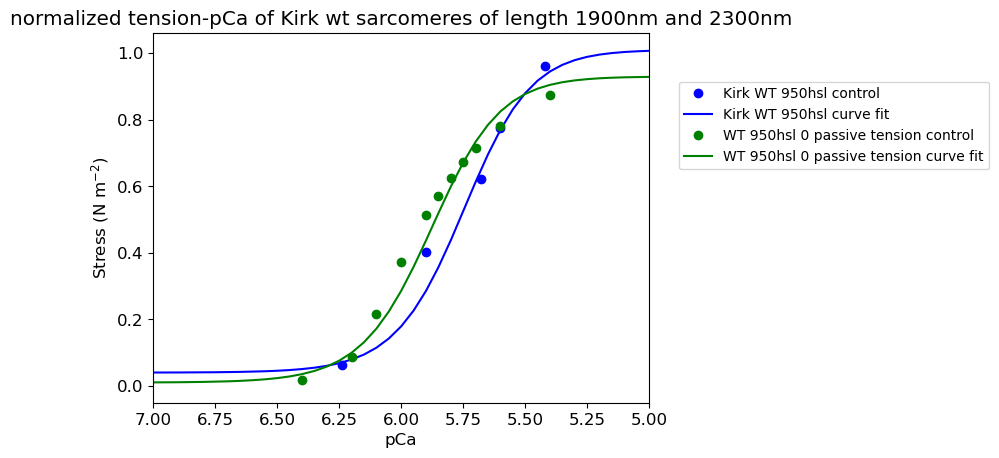

'/Users/alecloftus/Desktop/ABLIM_CG_Extended_Analyses/tension_pCa'

In [264]:
#Normalized MATLAB LDA tension-pCa KIRK data


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit


x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl950'
wt=csv_file + '_kforce5.csv'
#print(wt)
gsk=csv_file + '_kforce174.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))

normalized_wt=[]
for i in range(len(list_of_wt)):
    normalized_wt.append(list_of_wt[i]/max(list_of_wt))
list_of_wt=normalized_wt
#print(list_of_wt)

gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
#print(list_of_gsk)


normalized_gsk=[]
for i in range(len(list_of_gsk)):
    normalized_gsk.append(list_of_gsk[i]/max(list_of_gsk))

list_of_gsk=normalized_gsk

#print(list_of_gsk)

fig,ax = plt.subplots()



plt.xlim(4,7)
plt.gca().invert_xaxis()

wt50=5.81
gsk50=5.51
F=0.84
G=0.89



def hill_function(F,Ca50,Ca,n):
    return (F+0.02)/(1+(Ca50/Ca)**n)-0.02



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-130))

#print(line_items)
#for i in range(
    
#hill_co=2

def hill_GSK_function(G,Ca50,Ca,n):
    return (G+0.03)/(1+(Ca50/Ca)**n)-0.03



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-60))



    
#WT PASSIVE 0 HILL FUNCTION#
csv_file='hsl950'
passive=csv_file + '_kforce5_klin14_slack950.csv'
passive_obj = open(passive, 'r')
passive_csv = csv.reader(passive_obj)
#print(gsk_csv)
list_of_passive = list(passive_csv)
list_of_passive = list_of_passive[0]
#print(list_of_gsk)

for i in range(len(list_of_passive)):
    list_of_passive[i]=float(list_of_passive[i])
print(list_of_passive)

normalized_passive=[]
for i in range(len(list_of_passive)):
    normalized_passive.append(list_of_passive[i]/max(list_of_passive))

P=0.92
p50=5.88
def hill_function(P,Ca50,Ca,n):
    return P/(1+(Ca50/Ca)**n)+0.01

passive_sequence=[]
y=4.0
for i in range(0,1000):
    passive_sequence.append(y)
    y+=0.05

passive_line_items=[]
for Ca in passive_sequence:
    passive_line_items.append(hill_function(P,p50,Ca,-42))




#GSK PASSIVE 0 HILL FUNCTION#
long_csv_file='hsl950'
long_passive=long_csv_file + '_kforce174_klin14_slack950.csv'
long_passive_obj = open(long_passive, 'r')
long_passive_csv = csv.reader(long_passive_obj)
#print(gsk_csv)
long_list_of_passive = list(long_passive_csv)
long_list_of_passive = long_list_of_passive[0]
#print(list_of_gsk)

for i in range(len(long_list_of_passive)):
    long_list_of_passive[i]=float(long_list_of_passive[i])
#print(long_list_of_passive)

normalized_long_passive=[]
for i in range(len(long_list_of_passive)):
    normalized_long_passive.append(long_list_of_passive[i]/max(long_list_of_passive))

long_P=0.92
long_p50=5.556
def hill_function(long_P,Ca50,Ca,n):
    return long_P/(1+(Ca50/Ca)**n)+0.02

long_passive_sequence=[]
y=4.0
for i in range(0,1000):
    long_passive_sequence.append(y)
    y+=0.05

long_passive_line_items=[]
for Ca in long_passive_sequence:
    long_passive_line_items.append(hill_function(long_P,long_p50,Ca,-38))







#KIRK DATA
 
list_of_short_kirk = [10000,65000,100000,125000,155000,161000]
list_of_long_kirk = [52000,113000,159000,178000,189000,222000]

normalized_short_kirk=[]
for i in range(len(list_of_short_kirk)):
    normalized_short_kirk.append(list_of_short_kirk[i]/max(list_of_short_kirk))


normalized_long_kirk=[]
for i in range(len(list_of_long_kirk)):
    normalized_long_kirk.append(list_of_long_kirk[i]/max(list_of_long_kirk))

print(normalized_short_kirk)
print(normalized_long_kirk)

short_kirk_pCa50=5.75
long_kirk_pCa50=5.86

short_K=0.97
long_K=0.90
kirk_x_values=[6.24,5.9,5.68,5.6,5.42,4.4]

def short_kirk_hill_function(short_K,Ca50,Ca,n):
    return short_K/(1+(Ca50/Ca)**n)+0.04

def long_kirk_hill_function(long_K,Ca50,Ca,n):
    return long_K/(1+(Ca50/Ca)**n)+0.05
short_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    short_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

short_kirk_line_items=[]
for Ca in short_kirk_sequence:
    short_kirk_line_items.append(short_kirk_hill_function(short_K,short_kirk_pCa50,Ca,-42))

long_kirk_sequence=[]
y=4.0
for i in range(0,1000):
    long_kirk_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_kirk_line_items=[]
for Ca in long_kirk_sequence:
    long_kirk_line_items.append(long_kirk_hill_function(long_K,long_kirk_pCa50,Ca,-37))

plt.plot(kirk_x_values,normalized_short_kirk,'bo',label='Kirk WT 950hsl control')
#plt.plot(kirk_x_values,normalized_long_kirk,'o',label='Kirk WT 1150hsl control',color='cornflowerblue')
plt.plot(short_kirk_sequence,short_kirk_line_items,'b-',label='Kirk WT 950hsl curve fit')
#plt.plot(long_kirk_sequence,long_kirk_line_items,'-',label='Kirk WT 1150hsl curve fit',color='cornflowerblue')

plt.plot(x_values,normalized_passive,'go',label='WT 950hsl 0 passive tension control')
#plt.plot(x_values,normalized_long_passive,'o',label='WT 1150hsl 0 passive tension control', color='palegreen')
plt.plot(passive_sequence,passive_line_items,'g-',label='WT 950hsl 0 passive tension curve fit')
#plt.plot(long_passive_sequence,long_passive_line_items,'-',label='WT 1150hsl 0 passive tension curve fit',color='palegreen')

plt.legend()
plt.legend(bbox_to_anchor=(1.70,0.75),loc='center right',fontsize=10)
plt.xlim(7.0,5.0)

title="normalized tension-pCa of Kirk wt sarcomeres of length 1900nm and 2300nm"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
#ax.figure.set_size_inches(10.0,5.5)
name='pCa_normal_kirk.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=600,bbox_inches='tight')
plt.show()
os.getcwd()

[-0.02860225276343179, -0.020894829699549852, -0.016205816377707894, -0.012886053228911796, -0.008719910438904169, -0.0035801297897287243, -0.0006282294448966959, 0.5998149967316843, 0.6511075125178831, 0.6960593698597114, 0.7695740165883526, 0.8684728171368917, 1.0]
[-4407.10720472144, -3219.52803060485, -2497.03303817737, -1985.51556394075, -1343.5857810806, -551.635422588938, -96.7991764747339, 2028.41409399527, 5424.77552756568, 11353.5935416821, 35661.9235029201, 63514.8813202462, 95608.3497140811]
[-0.04609542176913411, -0.03367413034774599, -0.026117311360825735, -0.02076717744714221, -0.014053017179970404, -0.005769741076366406, -0.0010124552590251165, 0.0212158676523681, 0.056739558247669714, 0.11875106698981076, 0.373000094757078, 0.6643235816765886, 1.0]
[-0.005130551110814799, 0.007511376689774443, 0.11092971265526236, 0.26638632239482934, 0.41656511229961946, 0.5446511887547788, 0.5996423461610296, 0.6487931951141312, 0.6924685212644983, 0.7311029536588498, 0.7951160030764

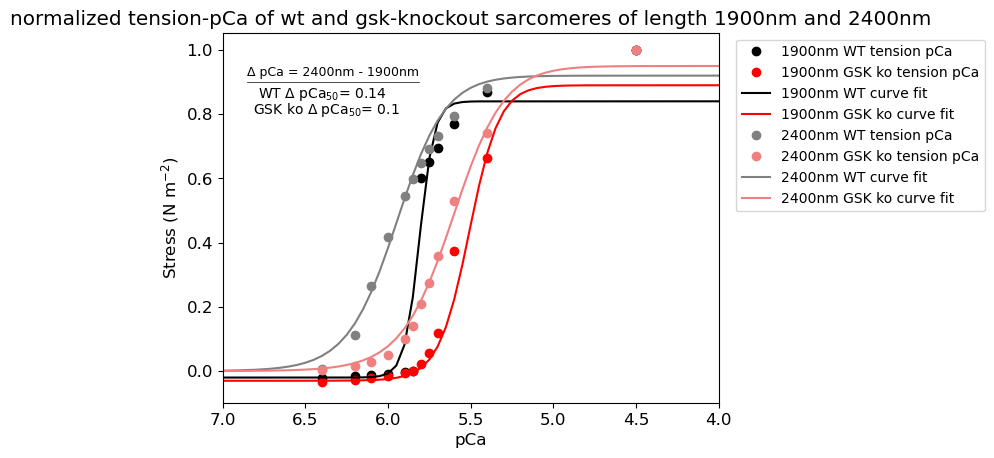

'/Users/alecloftus/Desktop/ABLIM_CG_Extended_Analyses/tension_pCa'

In [13]:
#Normalized MATLAB LDA tension-pCa 


import numpy as np;
import scipy.optimize as opt;
from scipy.optimize import curve_fit


x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]

import csv 

csv_file='hsl950'
wt=csv_file + '_kforce5.csv'
#print(wt)
gsk=csv_file + '_kforce174.csv'
#wt_obj = open(wt, 'r')



wt_obj = open(wt, 'r')
wt_csv = csv.reader(wt_obj)

#print(wt_csv)
list_of_wt = list(wt_csv) 
list_of_wt = list_of_wt[0]
#print(list_of_wt)
for i in range(len(list_of_wt)):
    list_of_wt[i]=float(list_of_wt[i])
#print(type(list_of_wt[0]))

normalized_wt=[]
for i in range(len(list_of_wt)):
    normalized_wt.append(list_of_wt[i]/max(list_of_wt))
list_of_wt=normalized_wt
print(list_of_wt)

gsk_obj = open(gsk, 'r')
gsk_csv = csv.reader(gsk_obj)
#print(gsk_csv)
list_of_gsk = list(gsk_csv)
list_of_gsk = list_of_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_gsk)):
    list_of_gsk[i]=float(list_of_gsk[i])
print(list_of_gsk)


normalized_gsk=[]
for i in range(len(list_of_gsk)):
    normalized_gsk.append(list_of_gsk[i]/max(list_of_gsk))

list_of_gsk=normalized_gsk

print(list_of_gsk)

fig,ax = plt.subplots()



plt.xlim(4,7)
plt.gca().invert_xaxis()

wt50=5.81
gsk50=5.51
F=0.84
G=0.89



def hill_function(F,Ca50,Ca,n):
    return (F+0.02)/(1+(Ca50/Ca)**n)-0.02



pCa_sequence=[]
y=4.0
for i in range(0,1000):
    pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

line_items=[]
for Ca in pCa_sequence:
    line_items.append(hill_function(F,wt50,Ca,-130))

#print(line_items)
#for i in range(
    
#hill_co=2

def hill_GSK_function(G,Ca50,Ca,n):
    return (G+0.03)/(1+(Ca50/Ca)**n)-0.03



GSK_sequence=[]
y=4.0
for i in range(0,1000):
    GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

gsk_line_items=[]
for Ca in GSK_sequence:
    gsk_line_items.append(hill_GSK_function(G,gsk50,Ca,-60))




#plot 1900nm stuff
plt.plot(x_values,list_of_wt,'ko',label='1900nm WT tension pCa')
plt.plot(x_values,list_of_gsk,'ro',label='1900nm GSK ko tension pCa')
plt.plot(pCa_sequence,line_items,'k-',label='1900nm WT curve fit')
plt.plot(GSK_sequence,gsk_line_items,'r-',label='1900nm GSK ko curve fit')


long_csv='hsl1200'
#LONG STUFF
long_wt=long_csv + '_kforce5.csv'
#print(wt)
long_gsk=long_csv + '_kforce174.csv'
#wt_obj = open(wt, 'r')



long_wt_obj = open(long_wt, 'r')
long_wt_csv = csv.reader(long_wt_obj)

#print(wt_csv)
list_of_long_wt = list(long_wt_csv) 
list_of_long_wt = list_of_long_wt[0]
#print(list_of_wt)
for i in range(len(list_of_long_wt)):
    list_of_long_wt[i]=float(list_of_long_wt[i])
#print(type(list_of_wt[0]))

normalized_long_wt=[]
for i in range(len(list_of_long_wt)):
    normalized_long_wt.append(list_of_long_wt[i]/max(list_of_long_wt))

list_of_long_wt=normalized_long_wt

print(list_of_long_wt)


long_gsk_obj = open(long_gsk, 'r')
long_gsk_csv = csv.reader(long_gsk_obj)
#print(gsk_csv)
list_of_long_gsk = list(long_gsk_csv)
list_of_long_gsk = list_of_long_gsk[0]
#print(list_of_gsk)

for i in range(len(list_of_long_gsk)):
    list_of_long_gsk[i]=float(list_of_long_gsk[i])


normalized_long_gsk=[]
for i in range(len(list_of_long_gsk)):
    normalized_long_gsk.append(list_of_long_gsk[i]/max(list_of_long_gsk))

list_of_long_gsk=normalized_long_gsk

print(list_of_long_gsk)


long_wt50=5.95
long_gsk50=5.61
long_F=0.92
long_G=0.95


def long_hill_function(F,Ca50,Ca,n):
    return F/(1+(Ca50/Ca)**n)

def long_hill_GSK_function(G,Ca50,Ca,n):
    return G/(1+(Ca50/Ca)**n)

long_pCa_sequence=[]
y=4.0
for i in range(0,1000):
    long_pCa_sequence.append(y)
    y+=0.05
#print(pCa_sequence)

long_line_items=[]
for Ca in long_pCa_sequence:
    long_line_items.append(long_hill_function(long_F,long_wt50,Ca,-40))



long_GSK_sequence=[]
y=4.0
for i in range(0,1000):
    long_GSK_sequence.append(y)
    y+=0.05
#print(GSK_sequence)

long_gsk_line_items=[]
for Ca in long_GSK_sequence:
    long_gsk_line_items.append(long_hill_GSK_function(long_G,long_gsk50,Ca,-36))


#plot 2600nm stuff
plt.plot(x_values,list_of_long_wt,'o',label='2400nm WT tension pCa',color='gray')
plt.plot(x_values,list_of_long_gsk,'o',label='2400nm GSK ko tension pCa',color='lightcoral')
plt.plot(long_pCa_sequence,long_line_items,'-',label='2400nm WT curve fit',color='gray')
plt.plot(long_GSK_sequence,long_gsk_line_items,'-',label='2400nm GSK ko curve fit',color='lightcoral')

'''
plt.plot([6.45,6.036],[169000,169000],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.45,170000,"\u0394 pCa = 2400nm - 1900nm", fontsize=9)
plt.text(6.386,161000,text,fontsize=9)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.416,154000,gsk_text,fontsize=9)
'''
plt.plot([6.85,5.81],[0.9,0.9],color='black',linewidth=0.5)
wt_delta50=round(long_wt50-wt50,3)
text="WT \u0394 pCa$_{50}$= "+str(wt_delta50)
plt.text(6.85,0.92,"\u0394 pCa = 2400nm - 1900nm", fontsize=9)
plt.text(6.786,0.85,text,fontsize=10)
gsk_delta50=round(long_gsk50-gsk50,3)
gsk_text="GSK ko \u0394 pCa$_{50}$= "+str(gsk_delta50)
plt.text(6.816,0.8,gsk_text,fontsize=10)
plt.legend()
plt.legend(bbox_to_anchor=(1.55,0.75),loc='center right',fontsize=10)


title="normalized tension-pCa of wt and gsk-knockout sarcomeres of length 1900nm and 2400nm"
plt.title(title)

plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
#ax.figure.set_size_inches(10.0,5.5)
name='pCa_hsl950_vs_hsl1200_normal.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300,bbox_inches='tight')
plt.show()
os.getcwd()

hsl800
hsl850
hsl950
hsl1050
hsl1100
hsl1200
hsl1300
hsl1350


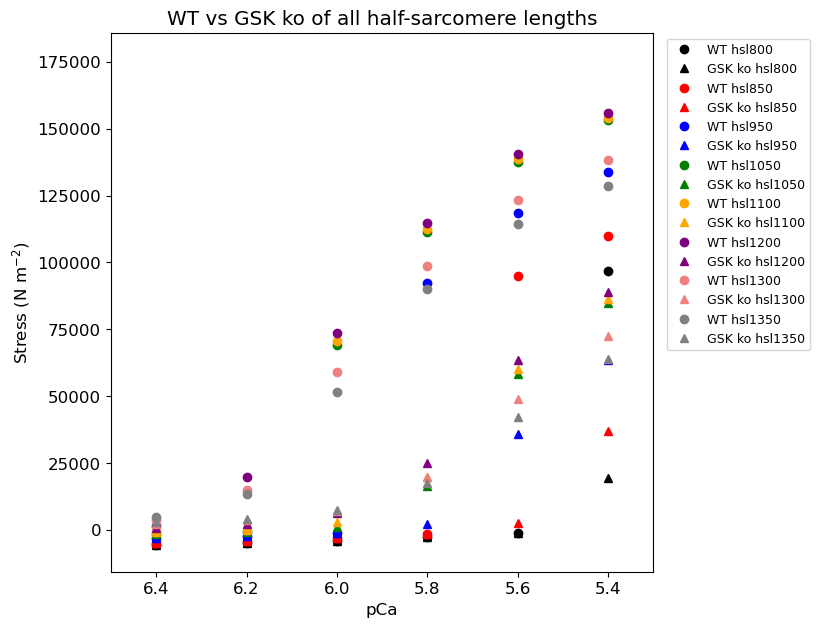

In [34]:
#MATLAB LDA tension-pCa
#csv_files=['hsl950','hsl1050','hsl1100','hsl1200','hsl1300']

x_values=[9,6.4,6.2,6,5.8,5.6,5.4,4.5]
#x_values=[9,6.4,6.2,6.1,6,5.9,5.85,5.8,5.75,5.7,5.6,5.4,4.5]


csv_files=['hsl800','hsl850','hsl950','hsl1050','hsl1100','hsl1200','hsl1300','hsl1350']
colors=['black','red','blue','green','orange','purple','lightcoral','gray','lightblue']
color_num=0
fig,ax = plt.subplots()

for csv_file in csv_files:
    wt=csv_file + '_kforce5.csv'

    gsk=csv_file + '_kforce174.csv'
    
    wt_obj = open(wt, 'r')
    wt_csv = csv.reader(wt_obj)
    #if csv_file='hsl950':
    
    #print(wt_csv)
    list_of_wt = list(wt_csv) 
    list_of_wt = list_of_wt[0]
    print(csv_file)
    if csv_file=='hsl950' or csv_file=='hsl1200':
        segments=[0,1,2,4,7,10,11,12]
        new_list=[]
        for segment in segments:
            #print(segment)
            #print(list_of_wt[segment])
            new_list.append(list_of_wt[segment])
            #list_of_wt=list_of_wt[0:2].extend(list_of_wt[4] + list_of_wt[7] + list_of_wt[10:])
        #print(new_list)
        list_of_wt=new_list
    #print(list_of_wt)
    for i in range(len(list_of_wt)):
        list_of_wt[i]=float(list_of_wt[i])
    #print(list_of_wt)
    gsk_obj = open(gsk, 'r')
    gsk_csv = csv.reader(gsk_obj)
    #print(gsk_csv)
    list_of_gsk = list(gsk_csv)
    list_of_gsk = list_of_gsk[0]
    #print(list_of_gsk)
    if csv_file=='hsl950' or csv_file=='hsl1200':
        segments=[0,1,2,4,7,10,11,12]
        new_list=[]
        for segment in segments:
            #print(segment)
            #print(list_of_gsk[segment])
            new_list.append(list_of_gsk[segment])
            #list_of_wt=list_of_wt[0:2].extend(list_of_wt[4] + list_of_wt[7] + list_of_wt[10:])
        #print(new_list)
        list_of_gsk=new_list
    
    for i in range(len(list_of_gsk)):
        list_of_gsk[i]=float(list_of_gsk[i])
    
    plt.xlim(5.3,6.5)
    #plt.ylim(-10000,175000)
    plt.gca().invert_xaxis()
    wt_classification="WT " + csv_file
    ax.plot(x_values,list_of_wt,'o',color=colors[color_num],label=wt_classification)
    gsk_classification="GSK ko " + csv_file
    ax.plot(x_values,list_of_gsk,'^',color=colors[color_num],label=gsk_classification)
    color_num+=1
plt.title("WT vs GSK ko of all half-sarcomere lengths")
ax.figure.set_size_inches(7.0,7.0)
plt.legend(bbox_to_anchor=(1.3,0.7),loc='center right',fontsize=9)
plt.xlabel("pCa")
plt.ylabel('Stress (N m$^{-2}$)')
name='LDA_pCa_all_lengths.png'
os.chdir(path)
plt.gcf().savefig(name,dpi=300)
plt.show()